In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
project_path = '/content/drive/MyDrive/deforestation_project'
os.makedirs(f'{project_path}/data/raw_imagery', exist_ok=True)
os.makedirs(f'{project_path}/data/labels', exist_ok=True)
os.makedirs(f'{project_path}/models/checkpoints', exist_ok=True)
os.makedirs(f'{project_path}/outputs/maps', exist_ok=True)
print("Folders created at:", project_path)

Folders created at: /content/drive/MyDrive/deforestation_project


In [5]:

!pip install earthengine-api geemap rasterio segmentation-models-pytorch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 134.8 MB/s eta 0:00:00


In [ ]:
import ee
ee.Authenticate()
ee.Initialize(project='deforestation-detection-500907')

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import rasterio
import geemap


In [ ]:
# Define an area
area = ee.Geometry.Rectangle([8.0, 4.8, 9.40, 6.9])

# Load Sentinel-2 image collection
collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(area) \
    .filterDate("2021-11-01", "2023-03-01") \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))

image = collection.median()

In [ ]:
sample = image.select(['B4', 'B3', 'B2']).reduceRegion(
    reducer=ee.Reducer.percentile([2, 98]),
    geometry=area,
    scale=100,
    maxPixels=1e9
).getInfo()

print(sample)

{'B2_p2': 48.20523639221805, 'B2_p98': 750.8546332741573, 'B3_p2': 305.9217561136477, 'B3_p98': 1038.8403558809073, 'B4_p2': 241.59069699693342, 'B4_p98': 1326.9386496830089}


In [ ]:
Map = geemap.Map()
Map.centerObject(area, zoom=8)
Map.addLayer(
    image,
    {"bands" : ["B4" , "B3", "B2"], "min":50, "max": 1327, "gamma": 1.4},
    "Sentinel-2 True Colour"
)

Map

Map(center=[5.849776080704363, 8.700000000000172], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
hansen = ee.Image('UMD/hansen/global_forest_change_2025_v1_13')
Loss_year = hansen.select('lossyear').clip(area)



In [ ]:
hansen_assets = ee.data.listAssets('UMD/hansen')
for asset in hansen_assets['assets']:
    print(asset['id'])

UMD/hansen/MODIS_2015
UMD/hansen/MODIS_2015_1
UMD/hansen/global_forest_change_2013
UMD/hansen/global_forest_change_2014
UMD/hansen/global_forest_change_2015
UMD/hansen/global_forest_change_2015_v1_3
UMD/hansen/global_forest_change_2016_v1_4
UMD/hansen/global_forest_change_2017_v1_5
UMD/hansen/global_forest_change_2018_v1_6
UMD/hansen/global_forest_change_2019_v1_7
UMD/hansen/global_forest_change_2020_v1_8
UMD/hansen/global_forest_change_2021_v1_9
UMD/hansen/global_forest_change_2022_v1_10
UMD/hansen/global_forest_change_2023_v1_11
UMD/hansen/global_forest_change_2024_v1_12
UMD/hansen/global_forest_change_2025_v1_13


In [ ]:
import ee

loss_viz = {
    "min": 1,
    "max": 25,
    "palette": ["yellow", "orange", "red"]
}
# Load Hansen data as an ee.Image asset
hansen = ee.Image("UMD/hansen/global_forest_change_2025_v1_13")
Loss_year = hansen.select("lossyear").clip(area)

Map = geemap.Map()
Map.centerObject(area, zoom=12)

Map.addLayer(
    image,
    {"bands" : ["B4" , "B3", "B2"], "min":50, "max": 1327, "gamma": 1.4},
    "Sentinel-2 True Colour"

)
Map

Map(center=[5.849776080704363, 8.700000000000172], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
# exporting data from earth engine as actual image files
task = ee.batch.Export.image.toDrive(
    image=image.select(['B8', 'B4', 'B3', 'B2']),
    description='sentinel2_crossriver',
    folder='deforestation_project/data/raw_imagery',
    region=area,
    scale=10,
    maxPixels=1e9
)
task.start()
print("Export started:", task.status())


Export started: {'state': 'READY', 'description': 'sentinel2_crossriver', 'priority': 100, 'creation_timestamp_ms': 1787649975536, 'update_timestamp_ms': 1787649975536, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': '7M2HW2XFDNHGHLMETU5EL6HQ', 'name': 'projects/deforestation-detection-500907/operations/7M2HW2XFDNHGHLMETU5EL6HQ'}


In [ ]:
task2 = ee.batch.Export.image.toDrive(
    image=Loss_year,
    description='hansen_lossyear_crossriver',
    folder='deforestation_project/data/labels',
    region=area,
    scale=30,
    maxPixels=1e9
)
task2.start()
print("Export started:", task2.status())

Export started: {'state': 'READY', 'description': 'hansen_lossyear_crossriver', 'priority': 100, 'creation_timestamp_ms': 1787650018299, 'update_timestamp_ms': 1787650018299, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': '5RZBQV6D6ELWDSR3YVKVJO54', 'name': 'projects/deforestation-detection-500907/operations/5RZBQV6D6ELWDSR3YVKVJO54'}


In [ ]:
import time

print("Waiting for Sentinel-2 export to complete...")
while task.status()['state'] == 'RUNNING' or task.status()['state'] == 'READY':
    print(f"Sentinel-2 export status: {task.status()['state']}")
    time.sleep(10)
print(f"Sentinel-2 export: {task.status()['state']}")

print("\nWaiting for Hansen export to complete...")
while task2.status()['state'] == 'RUNNING' or task2.status()['state'] == 'READY':
    print(f"Hansen export status: {task2.status()['state']}")
    time.sleep(10)
print(f"Hansen export: {task2.status()['state']}")

print("All exports completed.")

Waiting for Sentinel-2 export to complete...
Sentinel-2 export status: RUNNING
Sentinel-2 export status: RUNNING
Sentinel-2 export status: RUNNING
Sentinel-2 export status: RUNNING
Sentinel-2 export status: RUNNING
Sentinel-2 export status: RUNNING
Sentinel-2 export status: RUNNING
Sentinel-2 export status: RUNNING
Sentinel-2 export status: RUNNING
Sentinel-2 export status: RUNNING
Sentinel-2 export status: RUNNING
Sentinel-2 export status: RUNNING
Sentinel-2 export status: RUNNING
Sentinel-2 export status: RUNNING
Sentinel-2 export status: RUNNING
Sentinel-2 export status: RUNNING
Sentinel-2 export status: RUNNING
Sentinel-2 export status: RUNNING
Sentinel-2 export status: RUNNING
Sentinel-2 export status: RUNNING
Sentinel-2 export status: RUNNING
Sentinel-2 export status: RUNNING
Sentinel-2 export status: RUNNING
Sentinel-2 export status: RUNNING
Sentinel-2 export status: RUNNING
Sentinel-2 export status: RUNNING
Sentinel-2 export status: RUNNING
Sentinel-2 export status: RUNNING
Sen

In [ ]:
sentinel_path = '/content/drive/MyDrive/deforestation_project/data/raw_imagery/'
output_path = '/content/drive/MyDrive/deforestation_project/sentinel2_merged.tif'

!gdal_merge.py -o "{output_path}" \
    "{sentinel_path}sentinel2_crossriver-0000000000-0000000000.tif" \
    "{sentinel_path}sentinel2_crossriver-0000000000-0000011776.tif" \
    "{sentinel_path}sentinel2_crossriver-0000011776-0000000000.tif" \
    "{sentinel_path}sentinel2_crossriver-0000011776-0000011776.tif"

print("Merge complete")

0Traceback (most recent call last):
  File "/usr/local/bin/gdal_merge.py", line 14, in <module>
    sys.exit(main(sys.argv))
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/osgeo_utils/gdal_merge.py", line 650, in main
    return gdal_merge(argv)
           ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/osgeo_utils/gdal_merge.py", line 635, in gdal_merge
    fi.copy_into(t_fh, band, band, nodata, verbose)
  File "/usr/local/lib/python3.12/dist-packages/osgeo_utils/gdal_merge.py", line 348, in copy_into
    return raster_copy(
           ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/osgeo_utils/gdal_merge.py", line 117, in raster_copy
    t_band.WriteRaster(
  File "/usr/local/lib/python3.12/dist-packages/osgeo/gdal.py", line 5270, in WriteRaster
    return _gdal.Band_WriteRaster(self,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt
^C
Merge complete


In [ ]:
import os
import rasterio

sentinel_path = '/content/drive/MyDrive/deforestation_project/sentinel2_merged.tif'
hansen_path = '/content/drive/MyDrive/deforestation_project/data/labels/hansen_lossyear_crossriver.tif'

print("Sentinel exists:", os.path.exists(sentinel_path))
print("Hansen exists:", os.path.exists(hansen_path))

print("\nSentinel path:")
print(sentinel_path)

print("\nHansen path:")
print(hansen_path)

print("\nTesting Sentinel...")
try:
    with rasterio.open(sentinel_path) as src:
        print("✓ Sentinel opened")
        print("Shape:", src.count, src.height, src.width)
        print("CRS:", src.crs)
        print("Transform:", src.transform)
except Exception as e:
    print("❌ Sentinel error:")
    print(type(e).__name__, str(e))

print("\nTesting Hansen...")
try:
    with rasterio.open(hansen_path) as src:
        print("✓ Hansen opened")
        print("Shape:", src.count, src.height, src.width)
        print("CRS:", src.crs)
        print("Transform:", src.transform)
except Exception as e:
    print("❌ Hansen error:")
    print(type(e).__name__, str(e))

Sentinel exists: True
Hansen exists: False

Sentinel path:
/content/drive/MyDrive/deforestation_project/sentinel2_merged.tif

Hansen path:
/content/drive/MyDrive/deforestation_project/data/labels/hansen_lossyear_crossriver.tif

Testing Sentinel...
✓ Sentinel opened
Shape: 4 23384 15586
CRS: EPSG:4326
Transform: | 0.00, 0.00, 8.00|
| 0.00,-0.00, 6.90|
| 0.00, 0.00, 1.00|

Testing Hansen...
❌ Hansen error:
RasterioIOError /content/drive/MyDrive/deforestation_project/data/labels/hansen_lossyear_crossriver.tif: No such file or directory


In [ ]:
import rasterio

sentinel_path = '/content/drive/MyDrive/deforestation_project/sentinel2_merged.tif'
hansen_path = '/content/drive/MyDrive/deforestation_project/hansen_resampled.tif'

with rasterio.open(sentinel_path) as src:
    print("Sentinel-2 shape:", src.count, src.height, src.width)
    print("Sentinel-2 CRS:", src.crs)
    print("Sentinel-2 transform:", src.transform)

with rasterio.open(hansen_path) as src:
    print("Hansen shape:", src.count, src.height, src.width)
    print("Hansen CRS:", src.crs)
    print("Hansen transform:", src.transform)

Sentinel-2 shape: 4 23384 15586
Sentinel-2 CRS: EPSG:4326
Sentinel-2 transform: | 0.00, 0.00, 8.00|
| 0.00,-0.00, 6.90|
| 0.00, 0.00, 1.00|
Hansen shape: 1 23384 15586
Hansen CRS: EPSG:4326
Hansen transform: | 0.00, 0.00, 8.00|
| 0.00,-0.00, 6.90|
| 0.00, 0.00, 1.00|


In [ ]:
from rasterio.enums import Resampling

sentinel_path = '/content/drive/MyDrive/deforestation_project/sentinel2_merged.tif'
hansen_path = '/content/drive/MyDrive/deforestation_project data labels/hansen_lossyear_crossriver.tif'
hansen_resampled_path = '/content/drive/MyDrive/deforestation_project/hansen_resampled.tif'

with rasterio.open(sentinel_path) as sentinel_src:
    target_transform = sentinel_src.transform
    target_crs = sentinel_src.crs
    target_width = sentinel_src.width
    target_height = sentinel_src.height

with rasterio.open(hansen_path) as hansen_src:
    data = hansen_src.read(
        out_shape=(hansen_src.count, target_height, target_width),
        resampling=Resampling.nearest
    )

    with rasterio.open(
        hansen_resampled_path, 'w',
        driver='GTiff',
        height=target_height,
        width=target_width,
        count=1,
        dtype=data.dtype,
        crs=target_crs,
        transform=target_transform
    ) as dst:
        dst.write(data)

print("Hansen resampled and saved")

Hansen resampled and saved


In [ ]:
# ORIGINAL / ALL-YEAR DEFORESTATION MASK
import numpy as np

hansen_resampled_path = '/content/drive/MyDrive/deforestation_project/hansen_resampled.tif'
mask_path = '/content/drive/MyDrive/deforestation_project/deforestation_mask.tif'

with rasterio.open(hansen_resampled_path) as src:
    lossyear = src.read(1)
    profile = src.profile

    # Any pixel with lossyear > 0 means forest was lost — set to 1
    # Pixels with lossyear == 0 mean no loss — set to 0
    binary_mask = (lossyear > 0).astype(np.uint8)

    print(f"Total pixels: {binary_mask.size}")
    print(f"Deforested pixels: {binary_mask.sum()}")
    print(f"Deforestation %: {100 * binary_mask.sum() / binary_mask.size:.2f}%")

    # Save the binary mask
    profile.update(dtype=rasterio.uint8, count=1)
    with rasterio.open(mask_path, 'w', **profile) as dst:
        dst.write(binary_mask, 1)

print("Binary mask saved")

Total pixels: 364463024
Deforested pixels: 23318025


Deforestation %: 6.40%
Binary mask saved


In [ ]:
# FINAL EXPERIMENT — RECENT DEFORESTATION MASK (2018–2023)
import rasterio
import numpy as np

hansen_resampled_path = '/content/drive/MyDrive/deforestation_project/hansen_resampled.tif'
recent_mask_path = '/content/drive/MyDrive/deforestation_project/deforestation_mask_recent.tif'

with rasterio.open(hansen_resampled_path) as src:
    lossyear = src.read(1)
    profile = src.profile

    # Only keep RECENT loss (2018-2023)
    # Hansen values: 18=2018, 19=2019, 20=2020, 21=2021, 22=2022, 23=2023
    recent_mask = ((lossyear >= 18) & (lossyear <= 23)).astype(np.uint8)

    print(f"Total pixels: {recent_mask.size}")
    print(f"Recent deforested pixels: {recent_mask.sum()}")
    print(f"Recent deforestation %: {100 * recent_mask.sum() / recent_mask.size:.2f}%")

    profile.update(dtype=rasterio.uint8, count=1)
    with rasterio.open(recent_mask_path, 'w', **profile) as dst:
        dst.write(recent_mask, 1)

print("Recent deforestation mask saved")

Total pixels: 364463024
Recent deforested pixels: 9887505


Recent deforestation %: 2.71%
Recent deforestation mask saved


In [ ]:
import rasterio
import numpy as np

recent_mask_path = (
    '/content/drive/MyDrive/'
    'deforestation_project/'
    'deforestation_mask_recent.tif'
)

with rasterio.open(recent_mask_path) as src:

    mask = src.read(1)

    print("Mask shape:", mask.shape)
    print("Mask dtype:", mask.dtype)
    print("Unique values:", np.unique(mask))
    print("Positive pixels:", np.sum(mask == 1))
    print("Negative pixels:", np.sum(mask == 0))

Mask shape: (23384, 15586)
Mask dtype: uint8
Unique values: [0 1]
Positive pixels: 9887505
Negative pixels: 354575519


In [ ]:
import os

images_dir = '/content/drive/MyDrive/deforestation_project/patches/images'
masks_dir = '/content/drive/MyDrive/deforestation_project/patches/masks'

print("Images folder exists:", os.path.exists(images_dir))
print("Masks folder exists:", os.path.exists(masks_dir))

if os.path.exists(images_dir):
    image_files = [
        f for f in os.listdir(images_dir)
        if f.endswith('.npy')
    ]
    print("Image patches:", len(image_files))

if os.path.exists(masks_dir):
    mask_files = [
        f for f in os.listdir(masks_dir)
        if f.endswith('.npy')
    ]
    print("Mask patches:", len(mask_files))

Images folder exists: True
Masks folder exists: True
Image patches: 2877
Mask patches: 2877


In [ ]:
import os
import numpy as np

images_dir = '/content/drive/MyDrive/deforestation_project/patches/images'
masks_dir = '/content/drive/MyDrive/deforestation_project/patches/masks'

# Pick one patch
image_file = sorted(os.listdir(images_dir))[0]
mask_file = sorted(os.listdir(masks_dir))[0]

image = np.load(
    os.path.join(images_dir, image_file)
)

mask = np.load(
    os.path.join(masks_dir, mask_file)
)

print("IMAGE")
print("File:", image_file)
print("Shape:", image.shape)
print("Dtype:", image.dtype)
print()

print("MASK")
print("File:", mask_file)
print("Shape:", mask.shape)
print("Dtype:", mask.dtype)
print("Unique values:", np.unique(mask))

print()
print("Image and mask spatial dimensions match:",
      image.shape[-2:] == mask.shape[-2:])

IMAGE
File: patch_0.npy
Shape: (4, 256, 256)
Dtype: float64

MASK
File: patch_0.npy
Shape: (256, 256)
Dtype: uint8
Unique values: [0 1]

Image and mask spatial dimensions match: True


In [ ]:
import os
import numpy as np
import rasterio
from rasterio.windows import Window

sentinel_path = '/content/drive/MyDrive/deforestation_project/sentinel2_merged.tif'
mask_path = '/content/drive/MyDrive/deforestation_project/deforestation_mask.tif'

patches_dir = '/content/drive/MyDrive/deforestation_project/patches'
os.makedirs(f'{patches_dir}/images', exist_ok=True)
os.makedirs(f'{patches_dir}/masks', exist_ok=True)

patch_size = 256
stride = 256  # no overlap for now
min_deforestation = 0.01  # skip patches with less than 1% deforestation

patch_count = 0
skipped_count = 0

with rasterio.open(sentinel_path) as sent_src, \
     rasterio.open(mask_path) as mask_src:

    height, width = sent_src.height, sent_src.width

    for row in range(0, height - patch_size, stride):
        for col in range(0, width - patch_size, stride):
            window = Window(col, row, patch_size, patch_size)

            image_patch = sent_src.read(window=window)  # [4, 256, 256]
            mask_patch = mask_src.read(1, window=window)  # [256, 256]

            # Skip patches with almost no deforestation
            defor_ratio = mask_patch.sum() / (patch_size * patch_size)
            if defor_ratio < min_deforestation:
                skipped_count += 1
                continue

            # Save patches
            np.save(f'{patches_dir}/images/patch_{patch_count}.npy', image_patch)
            np.save(f'{patches_dir}/masks/patch_{patch_count}.npy', mask_patch)
            patch_count += 1

    print(f"Saved {patch_count} patches")
    print(f"Skipped {skipped_count} patches (too little deforestation)")

Saved 2877 patches
Skipped 2583 patches (too little deforestation)


In [ ]:
import segmentation_models_pytorch as smp
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=4,
    classes=1
).to(device)

# Combined loss
dice_loss = smp.losses.DiceLoss(mode='binary')
bce_loss = nn.BCEWithLogitsLoss()
focal_loss = smp.losses.FocalLoss(mode='binary')

def combined_loss(outputs, masks):
    return dice_loss(outputs, masks) + 0.5 * bce_loss(outputs, masks) + 0.5 * focal_loss(outputs, masks)

optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5
)

print("Device:", device)
print("Model and loss ready")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Device: cpu
Model and loss ready


In [ ]:
from torch.utils.data import Dataset
import torch

class DeforestationDataset(Dataset):
  def __init__(self, images_dir, masks_dir):
    self.images_dir = images_dir
    self.masks_dir = masks_dir
    self.patches = sorted(os.listdir(images_dir))
  def __len__(self):
    return len(self.patches)
  def __getitem__(self, idx):
    image = torch.from_numpy(np.load(f'{self.images_dir}/patch_{idx}.npy')).float()
    mask = torch.from_numpy(np.load(f'{self.masks_dir}/patch_{idx}.npy')).float().unsqueeze(0)
    image = image / 10000.0
    return image, mask

In [ ]:
# ============================================================
# FINAL REPRODUCIBLE SPLIT
# Existing 2,877 patches
# ============================================================

import random
import numpy as np
import torch
from torch.utils.data import random_split, DataLoader, Dataset
import os

SEED = 42

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ------------------------------------------------------------
# Dataset class definition (copied from fznLGNl2Qhus)
# ------------------------------------------------------------
class DeforestationDataset(Dataset):
  def __init__(self, images_dir, masks_dir):
    self.images_dir = images_dir
    self.masks_dir = masks_dir
    self.patches = sorted(os.listdir(images_dir))
  def __len__(self):
    return len(self.patches)
  def __getitem__(self, idx):
    image = torch.from_numpy(np.load(f'{self.images_dir}/patch_{idx}.npy')).float()
    mask = torch.from_numpy(np.load(f'{self.masks_dir}/patch_{idx}.npy')).float().unsqueeze(0)
    image = image / 10000.0
    return image, mask

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

images_dir = (
    "/content/drive/MyDrive/"
    "deforestation_project/patches/images"
)

masks_dir = (
    "/content/drive/MyDrive/"
    "deforestation_project/patches/masks"
)

dataset = DeforestationDataset(
    images_dir,
    masks_dir
)

print("\nTotal patches:", len(dataset))

# ------------------------------------------------------------
# Fixed split
# ------------------------------------------------------------

total = len(dataset)

train_size = int(0.70 * total)
val_size = int(0.15 * total)
test_size = total - train_size - val_size

generator = torch.Generator().manual_seed(SEED)

train_set, val_set, test_set = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=generator
)

train_loader = DataLoader(
    train_set,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_set,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_set,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

print("\n" + "=" * 50)
print("FINAL FIXED DATA SPLIT")
print("=" * 50)
print("Total:", len(dataset))
print("Train:", len(train_set))
print("Validation:", len(val_set))
print("Test:", len(test_set))
print("Seed:", SEED)
print("=" * 50)

Device: cuda
GPU: Tesla T4

Total patches: 2877

FINAL FIXED DATA SPLIT
Total: 2877
Train: 2013
Validation: 431
Test: 433
Seed: 42


In [11]:

# ============================================================
# RUN  — TRAIN VANILLA U-NET
# ============================================================

for epoch in range(VANILLA_EPOCHS):

    # --------------------------------------------------------
    # TRAINING
    # --------------------------------------------------------

    vanilla_model.train()

    running_loss = 0.0

    for images, masks in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )

        if masks.ndim == 3:
            masks = masks.unsqueeze(1)

        masks = masks.float()

        vanilla_optimizer.zero_grad(
            set_to_none=True
        )

        outputs = vanilla_model(images)

        loss = vanilla_loss(
            outputs,
            masks
        )

        loss.backward()

        vanilla_optimizer.step()

        running_loss += loss.item()

    avg_train_loss = (
        running_loss /
        len(train_loader)
    )

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    vanilla_model.eval()

    intersection = 0.0
    union = 0.0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            masks = masks.to(
                device,
                non_blocking=True
            )

            if masks.ndim == 3:
                masks = masks.unsqueeze(1)

            masks = masks.float()

            outputs = vanilla_model(images)

            preds = (
                torch.sigmoid(outputs) >= 0.5
            )

            intersection += (
                (preds & masks.bool())
                .float()
                .sum()
                .item()
            )

            union += (
                (preds | masks.bool())
                .float()
                .sum()
                .item()
            )

    val_iou = (
        intersection /
        (union + 1e-8)
    )

    vanilla_scheduler.step(val_iou)

    current_lr = vanilla_optimizer.param_groups[0]["lr"]

    # --------------------------------------------------------
    # PRINT
    # --------------------------------------------------------

    print(
        f"Epoch {epoch + 1:02d}/{VANILLA_EPOCHS} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val IoU: {val_iou:.4f} | "
        f"LR: {current_lr:.2e}"
    )

    # --------------------------------------------------------
    # SAVE BEST MODEL
    # --------------------------------------------------------

    if val_iou > best_vanilla_iou:

        best_vanilla_iou = val_iou

        torch.save(
            {
                "model_state_dict":
                    vanilla_model.state_dict(),

                "optimizer_state_dict":
                    vanilla_optimizer.state_dict(),

                "epoch":
                    epoch + 1,

                "val_iou":
                    val_iou,
            },
            VANILLA_PATH
        )

        print(
            f"   ✓ BEST VANILLA MODEL SAVED "
            f"(Val IoU = {best_vanilla_iou:.4f})"
        )


print("\n" + "=" * 60)
print("VANILLA U-NET TRAINING COMPLETE")
print("=" * 60)
print(
    f"Best Validation IoU: "
    f"{best_vanilla_iou:.4f}"
)
print(
    f"Checkpoint: {VANILLA_PATH}"
)
print("=" * 60)

Epoch 01/40 | Train Loss: 1.1980 | Val IoU: 0.2297 | LR: 1.00e-04
   ✓ BEST VANILLA MODEL SAVED (Val IoU = 0.2297)
Epoch 02/40 | Train Loss: 1.0997 | Val IoU: 0.1335 | LR: 1.00e-04
Epoch 03/40 | Train Loss: 1.0769 | Val IoU: 0.1647 | LR: 1.00e-04
Epoch 04/40 | Train Loss: 1.0786 | Val IoU: 0.2660 | LR: 1.00e-04
   ✓ BEST VANILLA MODEL SAVED (Val IoU = 0.2660)
Epoch 05/40 | Train Loss: 1.0610 | Val IoU: 0.2556 | LR: 1.00e-04
Epoch 06/40 | Train Loss: 1.0584 | Val IoU: 0.0891 | LR: 1.00e-04
Epoch 07/40 | Train Loss: 1.0491 | Val IoU: 0.2854 | LR: 1.00e-04
   ✓ BEST VANILLA MODEL SAVED (Val IoU = 0.2854)
Epoch 08/40 | Train Loss: 1.0493 | Val IoU: 0.0915 | LR: 1.00e-04
Epoch 09/40 | Train Loss: 1.0411 | Val IoU: 0.2043 | LR: 1.00e-04
Epoch 10/40 | Train Loss: 1.0315 | Val IoU: 0.1873 | LR: 1.00e-04
Epoch 11/40 | Train Loss: 1.0353 | Val IoU: 0.2231 | LR: 5.00e-05
Epoch 12/40 | Train Loss: 1.0132 | Val IoU: 0.2219 | LR: 5.00e-05
Epoch 13/40 | Train Loss: 0.9917 | Val IoU: 0.2511 | LR: 5.00

In [ ]:
# ============================================================
# RUN 1 — NORMAL RESNET34 U-NET
# 40 EPOCHS
# ============================================================

import torch
import torch.nn as nn
import segmentation_models_pytorch as smp

# ------------------------------------------------------------
# Create normal U-Net with ResNet34 encoder
# ------------------------------------------------------------

resnet_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=4,
    classes=1
).to(device)

print("Model: U-Net + ResNet34")
print("Device:", device)

# ------------------------------------------------------------
# Loss
# ------------------------------------------------------------

bce_loss = nn.BCEWithLogitsLoss()

def dice_loss(logits, targets, smooth=1.0):

    probs = torch.sigmoid(logits)

    intersection = (
        probs * targets
    ).sum()

    dice = (
        2 * intersection + smooth
    ) / (
        probs.sum()
        + targets.sum()
        + smooth
    )

    return 1 - dice


def normal_loss(logits, targets):

    return (
        bce_loss(logits, targets)
        + dice_loss(logits, targets)
    )

# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

optimizer = torch.optim.Adam(
    resnet_model.parameters(),
    lr=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

# ------------------------------------------------------------
# Checkpoint
# ------------------------------------------------------------

RESNET_PATH = (
    "/content/drive/MyDrive/"
    "deforestation_project/models/"
    "best_model_resnet34_final.pth"
)

EPOCHS = 40

best_val_iou = -1.0

print("\n" + "=" * 60)
print("STARTING NORMAL RESNET34 U-NET TRAINING")
print("=" * 60)
print("Epochs:", EPOCHS)
print("Batch size:", 4)
print("Learning rate:", 1e-4)
print("Checkpoint:", RESNET_PATH)
print("=" * 60)

Model: U-Net + ResNet34
Device: cuda

STARTING NORMAL RESNET34 U-NET TRAINING
Epochs: 40
Batch size: 4
Learning rate: 0.0001
Checkpoint: /content/drive/MyDrive/deforestation_project/models/best_model_resnet34_final.pth


In [ ]:
# ============================================================
# RUN 1 — TRAIN NORMAL RESNET34 U-NET
# ============================================================

for epoch in range(EPOCHS):

    # --------------------------------------------------------
    # TRAINING
    # --------------------------------------------------------

    resnet_model.train()

    running_loss = 0.0

    for images, masks in train_loader:

        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        # Make sure masks have shape [B, 1, H, W]
        if masks.ndim == 3:
            masks = masks.unsqueeze(1)

        masks = masks.float()

        optimizer.zero_grad(set_to_none=True)

        outputs = resnet_model(images)

        loss = normal_loss(
            outputs,
            masks
        )

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = (
        running_loss /
        len(train_loader)
    )

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    resnet_model.eval()

    intersection = 0.0
    union = 0.0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            if masks.ndim == 3:
                masks = masks.unsqueeze(1)

            masks = masks.float()

            outputs = resnet_model(images)

            preds = (
                torch.sigmoid(outputs) >= 0.5
            )

            intersection += (
                (preds & masks.bool())
                .float()
                .sum()
                .item()
            )

            union += (
                (preds | masks.bool())
                .float()
                .sum()
                .item()
            )

    val_iou = (
        intersection /
        (union + 1e-8)
    )

    scheduler.step(val_iou)

    current_lr = optimizer.param_groups[0]["lr"]

    # --------------------------------------------------------
    # PRINT RESULTS
    # --------------------------------------------------------

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val IoU: {val_iou:.4f} | "
        f"LR: {current_lr:.2e}"
    )

    # --------------------------------------------------------
    # SAVE BEST MODEL
    # --------------------------------------------------------

    if val_iou > best_val_iou:

        best_val_iou = val_iou

        torch.save(
            {
                "model_state_dict": resnet_model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "epoch": epoch + 1,
                "val_iou": val_iou,
            },
            RESNET_PATH
        )

        print(
            f"   ✓ BEST MODEL SAVED "
            f"(Val IoU = {best_val_iou:.4f})"
        )


print("\n" + "=" * 60)
print("RESNET34 U-NET TRAINING COMPLETE")
print("=" * 60)
print(f"Best Validation IoU: {best_val_iou:.4f}")
print(f"Checkpoint: {RESNET_PATH}")
print("=" * 60)

Epoch 01/40 | Train Loss: 1.2590 | Val IoU: 0.1940 | LR: 1.00e-04
   ✓ BEST MODEL SAVED (Val IoU = 0.1940)
Epoch 02/40 | Train Loss: 1.1191 | Val IoU: 0.2363 | LR: 1.00e-04
   ✓ BEST MODEL SAVED (Val IoU = 0.2363)
Epoch 03/40 | Train Loss: 1.0950 | Val IoU: 0.2101 | LR: 1.00e-04
Epoch 04/40 | Train Loss: 1.0908 | Val IoU: 0.2227 | LR: 1.00e-04
Epoch 05/40 | Train Loss: 1.0595 | Val IoU: 0.1127 | LR: 1.00e-04
Epoch 06/40 | Train Loss: 1.0545 | Val IoU: 0.2754 | LR: 1.00e-04
   ✓ BEST MODEL SAVED (Val IoU = 0.2754)
Epoch 07/40 | Train Loss: 1.0527 | Val IoU: 0.0800 | LR: 1.00e-04
Epoch 08/40 | Train Loss: 1.0472 | Val IoU: 0.0490 | LR: 1.00e-04
Epoch 09/40 | Train Loss: 1.0379 | Val IoU: 0.2881 | LR: 1.00e-04
   ✓ BEST MODEL SAVED (Val IoU = 0.2881)
Epoch 10/40 | Train Loss: 1.0369 | Val IoU: 0.2139 | LR: 1.00e-04
Epoch 11/40 | Train Loss: 1.0270 | Val IoU: 0.2359 | LR: 1.00e-04
Epoch 12/40 | Train Loss: 1.0280 | Val IoU: 0.2880 | LR: 1.00e-04
Epoch 13/40 | Train Loss: 1.0210 | Val IoU: 

In [ ]:
# ============================================================
# RUN 1 — RESNET34 TEST SET EVALUATION
# ============================================================

import numpy as np
import torch
from sklearn.metrics import precision_score, recall_score, f1_score

# ------------------------------------------------------------
# Load BEST ResNet34 checkpoint
# ------------------------------------------------------------

checkpoint = torch.load(
    RESNET_PATH,
    map_location=device
)

# Our checkpoint contains model_state_dict
if "model_state_dict" in checkpoint:
    resnet_model.load_state_dict(
        checkpoint["model_state_dict"]
    )
else:
    resnet_model.load_state_dict(checkpoint)

resnet_model.eval()

print("Loaded best ResNet34 model.")

if "epoch" in checkpoint:
    print("Best epoch:", checkpoint["epoch"])

if "val_iou" in checkpoint:
    print(
        f"Best validation IoU: "
        f"{checkpoint['val_iou']:.4f}"
    )

# ------------------------------------------------------------
# Test evaluation
# ------------------------------------------------------------

total_intersection = 0.0
total_union = 0.0

total_correct = 0
total_pixels = 0

all_preds = []
all_masks = []

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )

        if masks.ndim == 3:
            masks = masks.unsqueeze(1)

        masks = masks.float()

        outputs = resnet_model(images)

        preds = (
            torch.sigmoid(outputs) >= 0.5
        )

        # IoU
        total_intersection += (
            (preds & masks.bool())
            .float()
            .sum()
            .item()
        )

        total_union += (
            (preds | masks.bool())
            .float()
            .sum()
            .item()
        )

        # Accuracy
        total_correct += (
            (preds == masks.bool())
            .float()
            .sum()
            .item()
        )

        total_pixels += masks.numel()

        all_preds.append(
            preds.cpu()
            .numpy()
            .flatten()
        )

        all_masks.append(
            masks.cpu()
            .numpy()
            .flatten()
        )

# ------------------------------------------------------------
# Calculate metrics
# ------------------------------------------------------------

all_preds = np.concatenate(all_preds)
all_masks = np.concatenate(all_masks)

iou = (
    total_intersection /
    (total_union + 1e-8)
)

precision = precision_score(
    all_masks,
    all_preds,
    zero_division=0
)

recall = recall_score(
    all_masks,
    all_preds,
    zero_division=0
)

f1 = f1_score(
    all_masks,
    all_preds,
    zero_division=0
)

accuracy = (
    total_correct /
    total_pixels
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

resnet_results = {
    "IoU": iou,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "Accuracy": accuracy
}

print("\n" + "=" * 60)
print("RESNET34 U-NET — FINAL TEST RESULTS")
print("=" * 60)

for metric, value in resnet_results.items():
    print(f"{metric:<12}: {value:.4f}")

print("=" * 60)

Loaded best ResNet34 model.
Best epoch: 23
Best validation IoU: 0.3056

RESNET34 U-NET — FINAL TEST RESULTS
IoU         : 0.3109
Precision   : 0.4348
Recall      : 0.5216
F1          : 0.4743
Accuracy    : 0.8558


In [9]:
# ============================================================
# RUN 2 — VANILLA U-NET
# 40 EPOCHS
# ============================================================

import torch
import torch.nn as nn
import segmentation_models_pytorch as smp

# Define device for model training
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# ------------------------------------------------------------
# Vanilla U-Net
# No ResNet encoder
# ------------------------------------------------------------

vanilla_model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights=None,
    in_channels=4,
    classes=1
).to(device)

print("Model: Vanilla U-Net")
print("Device:", device)

# ------------------------------------------------------------
# Standard BCE + Dice loss
# ------------------------------------------------------------

bce_loss = nn.BCEWithLogitsLoss()


def dice_loss_vanilla(logits, targets, smooth=1.0):

    probs = torch.sigmoid(logits)

    intersection = (
        probs * targets
    ).sum()

    dice = (
        2 * intersection + smooth
    ) / (
        probs.sum()
        + targets.sum()
        + smooth
    )

    return 1 - dice


def vanilla_loss(logits, targets):

    return (
        bce_loss(logits, targets)
        + dice_loss_vanilla(logits, targets)
    )


# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

vanilla_optimizer = torch.optim.Adam(
    vanilla_model.parameters(),
    lr=1e-4
)

vanilla_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    vanilla_optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

# ------------------------------------------------------------
# Checkpoint
# ------------------------------------------------------------

VANILLA_PATH = (
    "/content/drive/MyDrive/"
    "deforestation_project/models/"
    "best_model_vanilla_final.pth"
)

VANILLA_EPOCHS = 40

best_vanilla_iou = -1.0

print("\n" + "=" * 60)
print("VANILLA U-NET READY")
print("=" * 60)
print("Epochs:", VANILLA_EPOCHS)
print("Batch size:", 4)
print("Learning rate:", 1e-4)
print("Checkpoint:", VANILLA_PATH)
print("=" * 60)

Model: Vanilla U-Net
Device: cuda

VANILLA U-NET READY
Epochs: 40
Batch size: 4
Learning rate: 0.0001
Checkpoint: /content/drive/MyDrive/deforestation_project/models/best_model_vanilla_final.pth


In [12]:
# ============================================================
# VANILLA U-NET — FINAL TEST SET EVALUATION
# ============================================================

import torch
import numpy as np
from torch.utils.data import DataLoader

# ------------------------------------------------------------
# Recreate the SAME test split
# ------------------------------------------------------------

SEED = 42

generator = torch.Generator().manual_seed(SEED)

total = len(dataset)

train_size = int(0.70 * total)
val_size = int(0.15 * total)
test_size = total - train_size - val_size

train_set, val_set, test_set = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=generator
)

test_loader = DataLoader(
    test_set,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

print("Test patches:", len(test_set))

# ------------------------------------------------------------
# Load BEST Vanilla checkpoint
# ------------------------------------------------------------

VANILLA_PATH = (
    "/content/drive/MyDrive/"
    "deforestation_project/models/"
    "best_model_vanilla_final.pth"
)

checkpoint = torch.load(
    VANILLA_PATH,
    map_location=device
)

vanilla_model.load_state_dict(
    checkpoint["model_state_dict"]
)

vanilla_model = vanilla_model.to(device)
vanilla_model.eval()

print("Best epoch:", checkpoint["epoch"])
print(
    "Best validation IoU:",
    f"{checkpoint['val_iou']:.4f}"
)

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

TP = 0
FP = 0
FN = 0
TN = 0

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )

        if masks.ndim == 3:
            masks = masks.unsqueeze(1)

        masks = masks.float()

        outputs = vanilla_model(images)

        probs = torch.sigmoid(outputs)

        preds = probs >= 0.5
        targets = masks >= 0.5

        TP += (
            (preds & targets)
            .sum()
            .item()
        )

        FP += (
            (preds & ~targets)
            .sum()
            .item()
        )

        FN += (
            (~preds & targets)
            .sum()
            .item()
        )

        TN += (
            (~preds & ~targets)
            .sum()
            .item()
        )

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

iou = TP / (TP + FP + FN + 1e-8)

precision = TP / (
    TP + FP + 1e-8
)

recall = TP / (
    TP + FN + 1e-8
)

f1 = 2 * precision * recall / (
    precision + recall + 1e-8
)

accuracy = (
    TP + TN
) / (
    TP + TN + FP + FN + 1e-8
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("VANILLA U-NET — FINAL TEST RESULTS")
print("=" * 60)

print(f"IoU         : {iou:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"F1          : {f1:.4f}")
print(f"Accuracy    : {accuracy:.4f}")

print("=" * 60)

Test patches: 433
Best epoch: 7
Best validation IoU: 0.2854

VANILLA U-NET — FINAL TEST RESULTS
IoU         : 0.3006
Precision   : 0.4107
Recall      : 0.5284
F1          : 0.4622
Accuracy    : 0.8466


In [15]:
# ============================================================
# LOAD IMPROVED RESNET34 U-NET + COMBINED LOSS CHECKPOINT
# ============================================================

import segmentation_models_pytorch as smp
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Recreate the exact architecture
improved_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=4,
    classes=1
).to(device)

# Load the trained weights
improved_checkpoint = (
    "/content/drive/MyDrive/"
    "deforestation_project/models/best_model.pth"
)

state_dict = torch.load(
    improved_checkpoint,
    map_location=device
)

improved_model.load_state_dict(state_dict)

improved_model.eval()

print("Improved model loaded successfully.")
print("Device:", device)

Improved model loaded successfully.
Device: cuda


In [16]:
# ============================================================
# IMPROVED MODEL — FINAL TEST RESULTS
# ============================================================

TP = 0
FP = 0
FN = 0
TN = 0

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )

        outputs = improved_model(images)

        preds = (
            torch.sigmoid(outputs) >= 0.5
        )

        targets = masks >= 0.5

        TP += (
            (preds & targets)
            .sum()
            .item()
        )

        FP += (
            (preds & ~targets)
            .sum()
            .item()
        )

        FN += (
            (~preds & targets)
            .sum()
            .item()
        )

        TN += (
            (~preds & ~targets)
            .sum()
            .item()
        )


# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

iou = TP / (
    TP + FP + FN + 1e-8
)

precision = TP / (
    TP + FP + 1e-8
)

recall = TP / (
    TP + FN + 1e-8
)

f1 = (
    2 * precision * recall /
    (precision + recall + 1e-8)
)

accuracy = (
    TP + TN
) / (
    TP + TN + FP + FN + 1e-8
)


print("\n" + "=" * 60)
print("IMPROVED RESNET34 U-NET — FINAL TEST RESULTS")
print("=" * 60)

print(f"IoU         : {iou:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"F1          : {f1:.4f}")
print(f"Accuracy    : {accuracy:.4f}")

print("=" * 60)


IMPROVED RESNET34 U-NET — FINAL TEST RESULTS
IoU         : 0.3133
Precision   : 0.3610
Recall      : 0.7035
F1          : 0.4772
Accuracy    : 0.8077


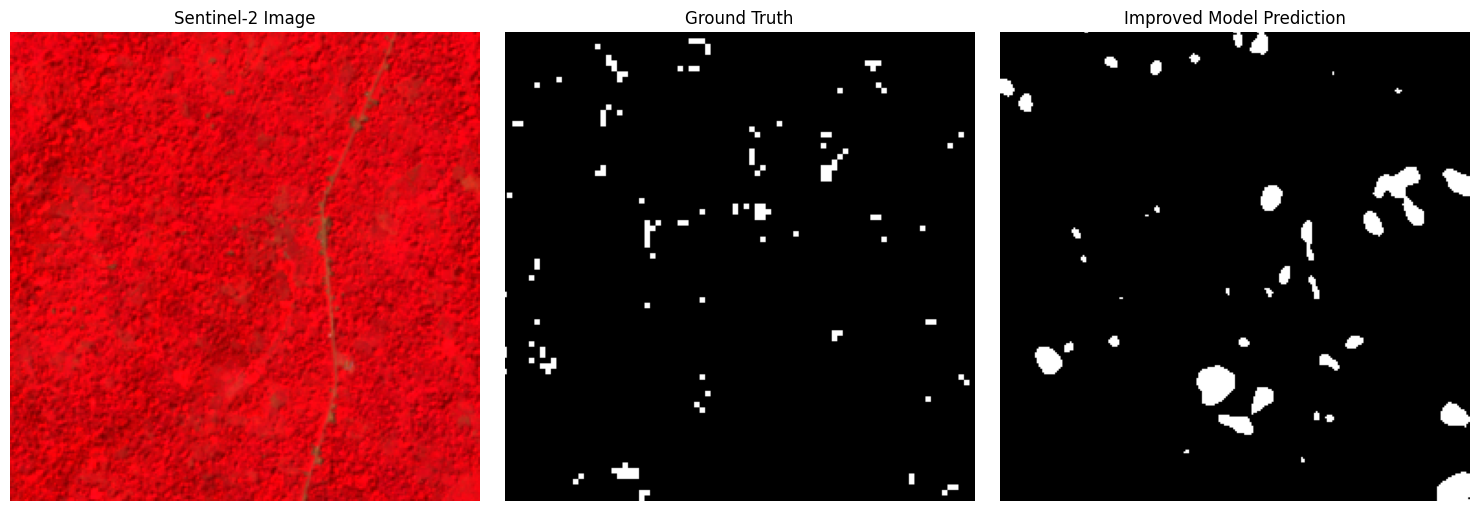

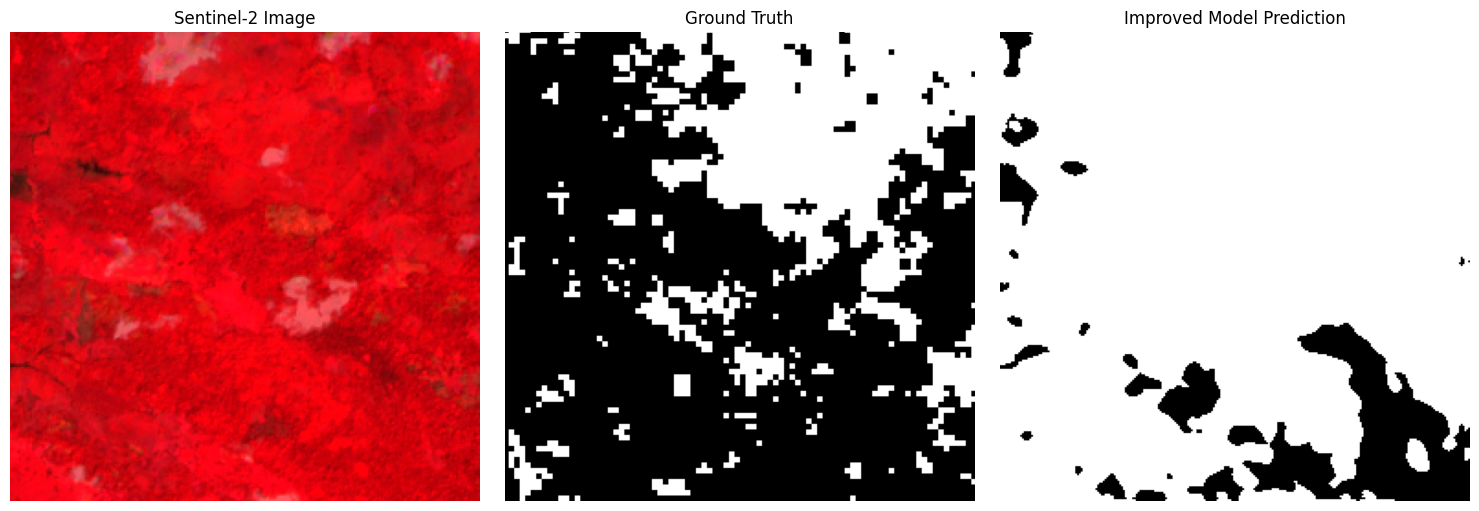

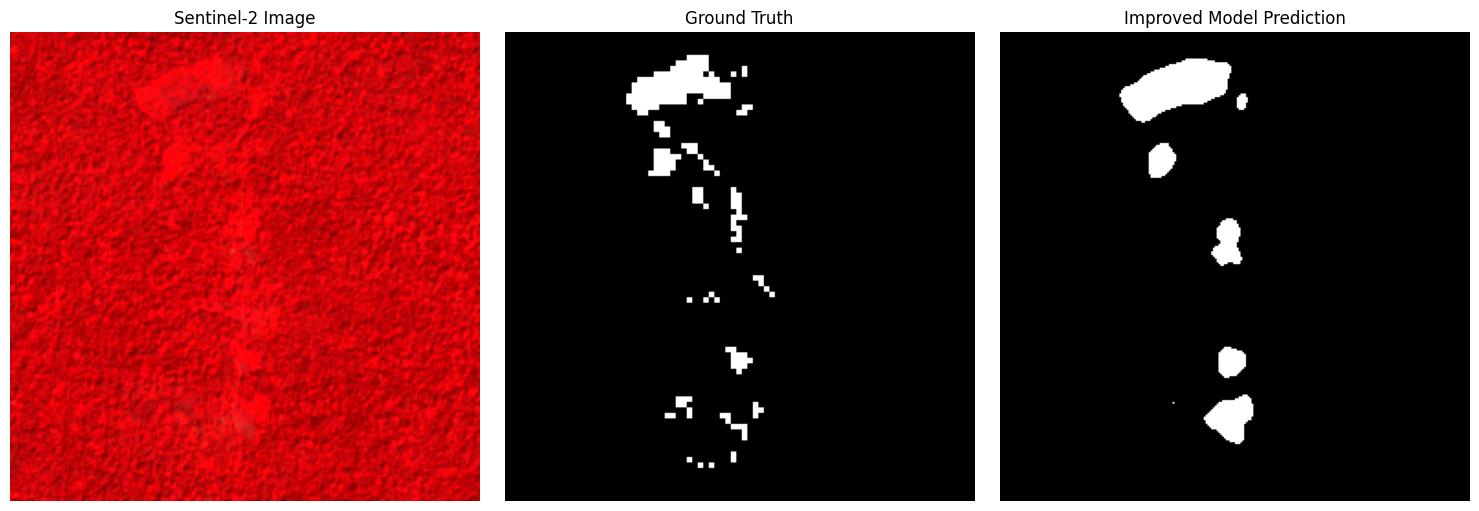

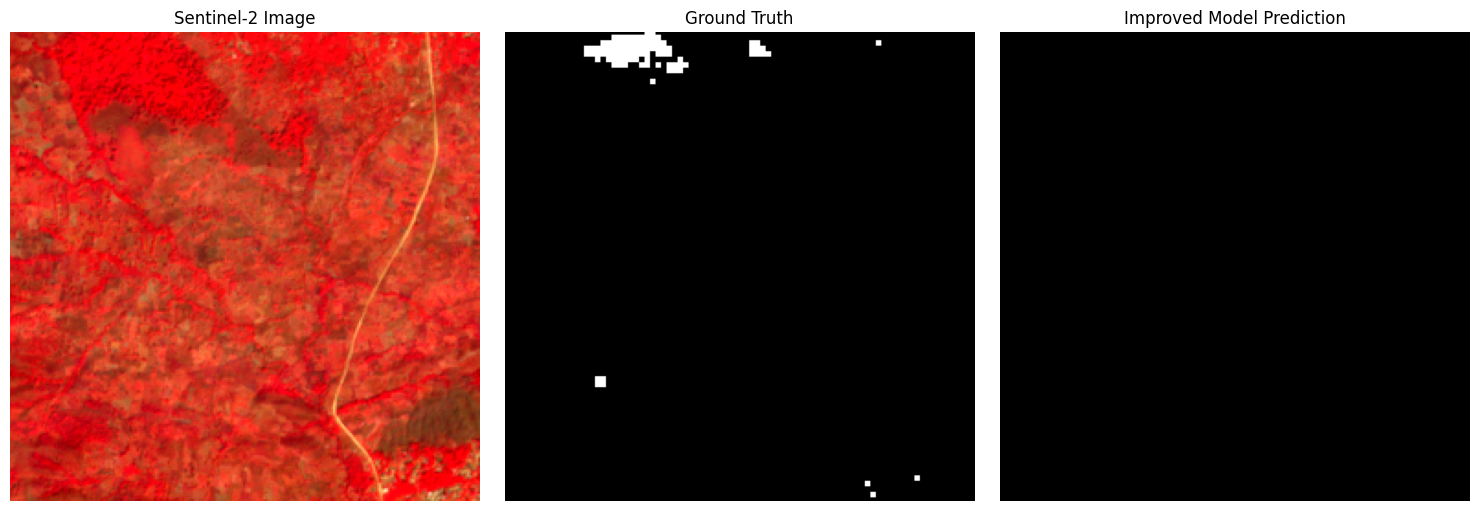

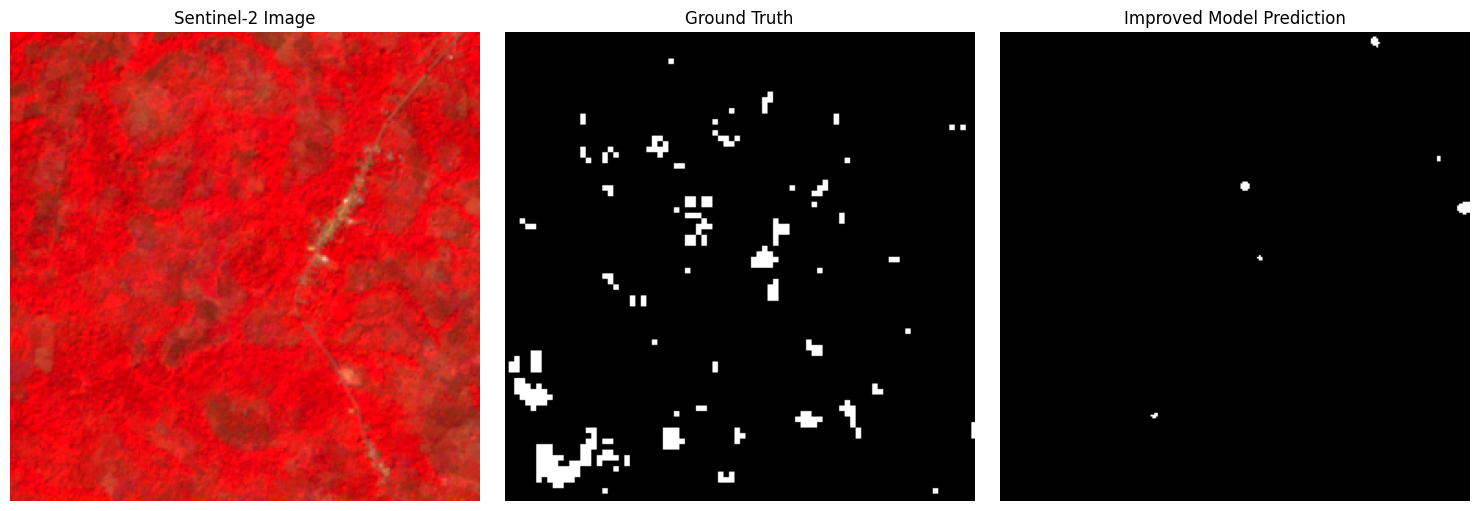

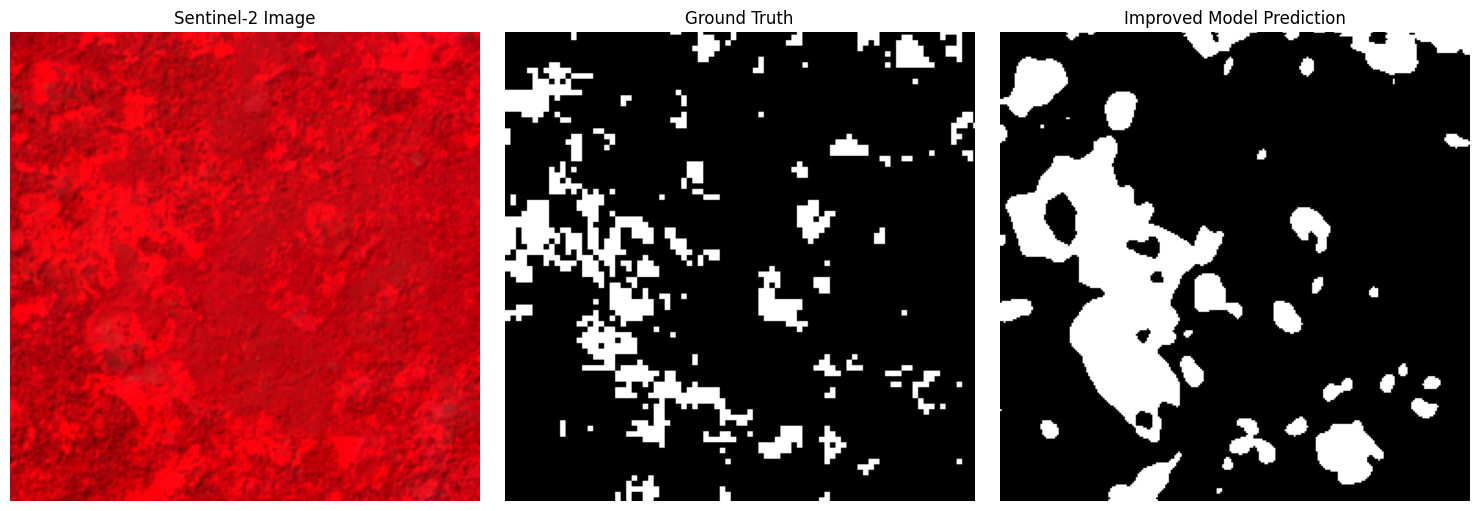

In [17]:
# ============================================================
# IMPROVED MODEL — PREDICTION MAPS
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import torch

# ------------------------------------------------------------
# Make sure improved model is in evaluation mode
# ------------------------------------------------------------

improved_model.eval()

# Number of examples to display
NUM_EXAMPLES = 6

shown = 0

with torch.no_grad():

    for images, masks in test_loader:

        images_gpu = images.to(device)

        outputs = improved_model(images_gpu)

        probabilities = torch.sigmoid(outputs)

        predictions = (
            probabilities >= 0.5
        ).float()

        for i in range(images.shape[0]):

            if shown >= NUM_EXAMPLES:
                break

            # ------------------------------------------------
            # Convert image to numpy
            # ------------------------------------------------

            image = images[i].cpu().numpy()

            # Sentinel-2 has 4 bands.
            # Display first three bands as RGB.
            rgb = image[:3]

            # Normalize for visualization
            rgb_min = np.percentile(rgb, 2)
            rgb_max = np.percentile(rgb, 98)

            rgb = np.clip(
                (rgb - rgb_min) /
                (rgb_max - rgb_min + 1e-8),
                0,
                1
            )

            rgb = np.transpose(
                rgb,
                (1, 2, 0)
            )

            # ------------------------------------------------
            # Ground truth
            # ------------------------------------------------

            ground_truth = (
                masks[i]
                .squeeze()
                .cpu()
                .numpy()
            )

            # ------------------------------------------------
            # Prediction
            # ------------------------------------------------

            prediction = (
                predictions[i]
                .squeeze()
                .cpu()
                .numpy()
            )

            # ------------------------------------------------
            # Plot
            # ------------------------------------------------

            fig, axes = plt.subplots(
                1,
                3,
                figsize=(15, 5)
            )

            axes[0].imshow(rgb)
            axes[0].set_title(
                "Sentinel-2 Image"
            )
            axes[0].axis("off")

            axes[1].imshow(
                ground_truth,
                cmap="gray"
            )
            axes[1].set_title(
                "Ground Truth"
            )
            axes[1].axis("off")

            axes[2].imshow(
                prediction,
                cmap="gray"
            )
            axes[2].set_title(
                "Improved Model Prediction"
            )
            axes[2].axis("off")

            plt.tight_layout()
            plt.show()

            shown += 1

        if shown >= NUM_EXAMPLES:
            break

In [18]:
# ============================================================
# IMPROVED MODEL — THRESHOLD ANALYSIS
# No retraining required
# ============================================================

import torch
import numpy as np

improved_model.eval()

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

results = []

with torch.no_grad():

    # Store probabilities and targets once
    all_probs = []
    all_targets = []

    for images, masks in test_loader:

        images = images.to(device)

        outputs = improved_model(images)

        probs = torch.sigmoid(outputs)

        all_probs.append(
            probs.cpu()
        )

        all_targets.append(
            masks.cpu()
        )

    all_probs = torch.cat(all_probs, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    # --------------------------------------------------------
    # Test each threshold
    # --------------------------------------------------------

    for threshold in thresholds:

        preds = all_probs >= threshold
        targets = all_targets >= 0.5

        TP = (
            (preds & targets)
            .sum()
            .item()
        )

        FP = (
            (preds & ~targets)
            .sum()
            .item()
        )

        FN = (
            (~preds & targets)
            .sum()
            .item()
        )

        TN = (
            (~preds & ~targets)
            .sum()
            .item()
        )

        iou = TP / (
            TP + FP + FN + 1e-8
        )

        precision = TP / (
            TP + FP + 1e-8
        )

        recall = TP / (
            TP + FN + 1e-8
        )

        f1 = 2 * precision * recall / (
            precision + recall + 1e-8
        )

        accuracy = (
            TP + TN
        ) / (
            TP + TN + FP + FN + 1e-8
        )

        results.append([
            threshold,
            iou,
            precision,
            recall,
            f1,
            accuracy
        ])


# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("IMPROVED MODEL — THRESHOLD ANALYSIS")
print("=" * 75)

print(
    f"{'Threshold':<12}"
    f"{'IoU':<12}"
    f"{'Precision':<12}"
    f"{'Recall':<12}"
    f"{'F1':<12}"
    f"{'Accuracy':<12}"
)

print("-" * 75)

for row in results:

    print(
        f"{row[0]:<12.2f}"
        f"{row[1]:<12.4f}"
        f"{row[2]:<12.4f}"
        f"{row[3]:<12.4f}"
        f"{row[4]:<12.4f}"
        f"{row[5]:<12.4f}"
    )

print("=" * 75)


IMPROVED MODEL — THRESHOLD ANALYSIS
Threshold   IoU         Precision   Recall      F1          Accuracy    
---------------------------------------------------------------------------
0.30        0.2425      0.2519      0.8675      0.3904      0.6621      
0.40        0.2828      0.3061      0.7875      0.4409      0.7509      
0.50        0.3133      0.3610      0.7035      0.4772      0.8077      
0.60        0.3312      0.4184      0.6137      0.4976      0.8454      
0.70        0.3252      0.5015      0.4806      0.4908      0.8757      
0.80        0.2655      0.5976      0.3233      0.4196      0.8885      


In [19]:
# ============================================================
# IMPROVED MODEL — VALIDATION THRESHOLD SELECTION
# ============================================================

import torch

improved_model.eval()

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

results = []

with torch.no_grad():

    # --------------------------------------------------------
    # Run validation set once
    # --------------------------------------------------------

    all_probs = []
    all_targets = []

    for images, masks in val_loader:

        images = images.to(device)

        outputs = improved_model(images)

        probs = torch.sigmoid(outputs)

        all_probs.append(
            probs.cpu()
        )

        all_targets.append(
            masks.cpu()
        )

    all_probs = torch.cat(
        all_probs,
        dim=0
    )

    all_targets = torch.cat(
        all_targets,
        dim=0
    )

    # --------------------------------------------------------
    # Test each threshold
    # --------------------------------------------------------

    for threshold in thresholds:

        preds = all_probs >= threshold
        targets = all_targets >= 0.5

        TP = (
            (preds & targets)
            .sum()
            .item()
        )

        FP = (
            (preds & ~targets)
            .sum()
            .item()
        )

        FN = (
            (~preds & targets)
            .sum()
            .item()
        )

        TN = (
            (~preds & ~targets)
            .sum()
            .item()
        )

        iou = TP / (
            TP + FP + FN + 1e-8
        )

        precision = TP / (
            TP + FP + 1e-8
        )

        recall = TP / (
            TP + FN + 1e-8
        )

        f1 = (
            2 * precision * recall /
            (precision + recall + 1e-8)
        )

        accuracy = (
            TP + TN
        ) / (
            TP + TN + FP + FN + 1e-8
        )

        results.append({
            "threshold": threshold,
            "iou": iou,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "accuracy": accuracy
        })


# ============================================================
# PRINT RESULTS
# ============================================================

print("\n" + "=" * 75)
print("IMPROVED MODEL — VALIDATION THRESHOLD ANALYSIS")
print("=" * 75)

print(
    f"{'Threshold':<12}"
    f"{'IoU':<12}"
    f"{'Precision':<12}"
    f"{'Recall':<12}"
    f"{'F1':<12}"
    f"{'Accuracy':<12}"
)

print("-" * 75)

for r in results:

    print(
        f"{r['threshold']:<12.2f}"
        f"{r['iou']:<12.4f}"
        f"{r['precision']:<12.4f}"
        f"{r['recall']:<12.4f}"
        f"{r['f1']:<12.4f}"
        f"{r['accuracy']:<12.4f}"
    )

print("=" * 75)


# ============================================================
# SELECT BEST THRESHOLD
# ============================================================

best_result = max(
    results,
    key=lambda x: x["f1"]
)

BEST_THRESHOLD = best_result["threshold"]

print("\nBEST VALIDATION THRESHOLD")
print("=" * 40)
print(f"Threshold : {BEST_THRESHOLD:.2f}")
print(f"Val IoU   : {best_result['iou']:.4f}")
print(f"Val F1    : {best_result['f1']:.4f}")
print(f"Precision : {best_result['precision']:.4f}")
print(f"Recall    : {best_result['recall']:.4f}")
print("=" * 40)



IMPROVED MODEL — VALIDATION THRESHOLD ANALYSIS
Threshold   IoU         Precision   Recall      F1          Accuracy    
---------------------------------------------------------------------------
0.30        0.2436      0.2533      0.8634      0.3917      0.6707      
0.40        0.2807      0.3039      0.7863      0.4384      0.7525      
0.50        0.3080      0.3542      0.7026      0.4710      0.8061      
0.60        0.3222      0.4054      0.6109      0.4874      0.8421      
0.70        0.3143      0.4852      0.4715      0.4783      0.8736      
0.80        0.2506      0.6001      0.3009      0.4008      0.8895      

BEST VALIDATION THRESHOLD
Threshold : 0.60
Val IoU   : 0.3222
Val F1    : 0.4874
Precision : 0.4054
Recall    : 0.6109


In [20]:
# ============================================================
# FINAL TEST EVALUATION
# Improved ResNet34 U-Net
# Threshold selected ONLY from validation set
# ============================================================

import torch

BEST_THRESHOLD = 0.60

improved_model.eval()

total_tp = 0
total_fp = 0
total_fn = 0
total_tn = 0

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = improved_model(images)

        probabilities = torch.sigmoid(outputs)

        predictions = (
            probabilities >= BEST_THRESHOLD
        )

        targets = masks >= 0.5

        total_tp += (
            predictions & targets
        ).sum().item()

        total_fp += (
            predictions & ~targets
        ).sum().item()

        total_fn += (
            ~predictions & targets
        ).sum().item()

        total_tn += (
            ~predictions & ~targets
        ).sum().item()


# ============================================================
# CALCULATE FINAL METRICS
# ============================================================

test_iou = total_tp / (
    total_tp +
    total_fp +
    total_fn +
    1e-8
)

test_precision = total_tp / (
    total_tp +
    total_fp +
    1e-8
)

test_recall = total_tp / (
    total_tp +
    total_fn +
    1e-8
)

test_f1 = (
    2 *
    test_precision *
    test_recall /
    (
        test_precision +
        test_recall +
        1e-8
    )
)

test_accuracy = (
    total_tp +
    total_tn
) / (
    total_tp +
    total_tn +
    total_fp +
    total_fn +
    1e-8
)


# ============================================================
# FINAL RESULTS
# ============================================================

print("\n" + "=" * 65)
print("IMPROVED RESNET34 U-NET — FINAL TEST RESULTS")
print("=" * 65)

print(f"Threshold   : {BEST_THRESHOLD:.2f}")
print(f"IoU         : {test_iou:.4f}")
print(f"Precision   : {test_precision:.4f}")
print(f"Recall      : {test_recall:.4f}")
print(f"F1          : {test_f1:.4f}")
print(f"Accuracy    : {test_accuracy:.4f}")

print("=" * 65)

print("\nConfusion counts:")
print(f"TP: {total_tp:,}")
print(f"FP: {total_fp:,}")
print(f"FN: {total_fn:,}")
print(f"TN: {total_tn:,}")


IMPROVED RESNET34 U-NET — FINAL TEST RESULTS
Threshold   : 0.60
IoU         : 0.3312
Precision   : 0.4184
Recall      : 0.6137
F1          : 0.4976
Accuracy    : 0.8454

Confusion counts:
TP: 2,172,008
FP: 3,018,744
FN: 1,367,021
TN: 21,819,315


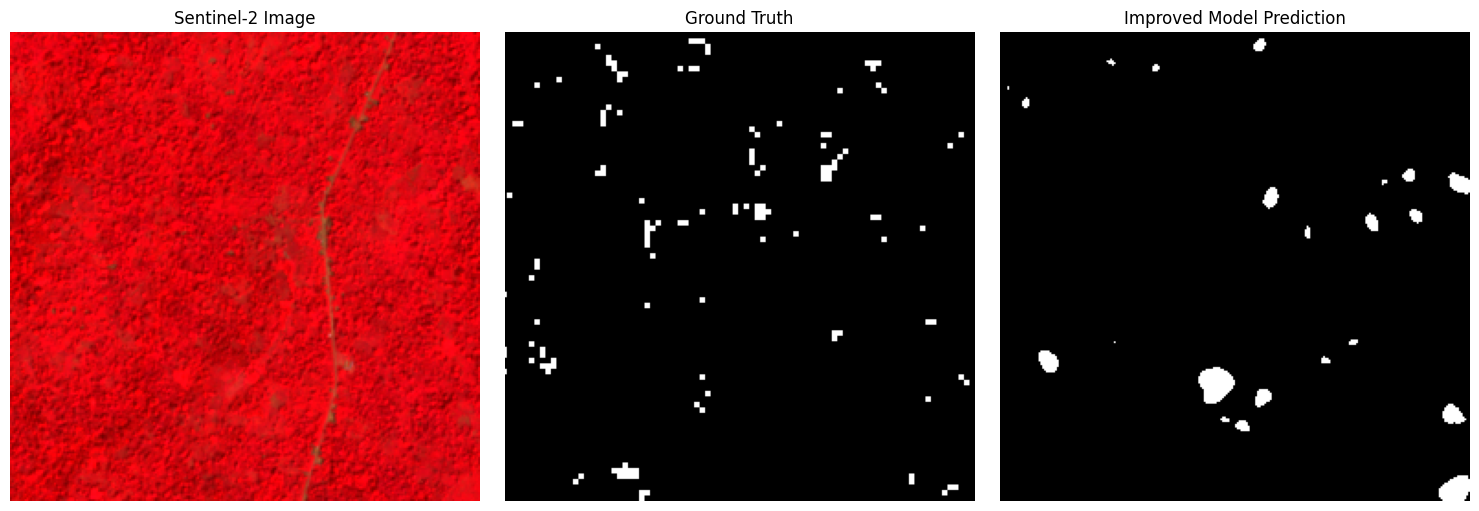

Saved: /content/drive/MyDrive/deforestation_project/outputs/prediction_maps/prediction_map_01.png


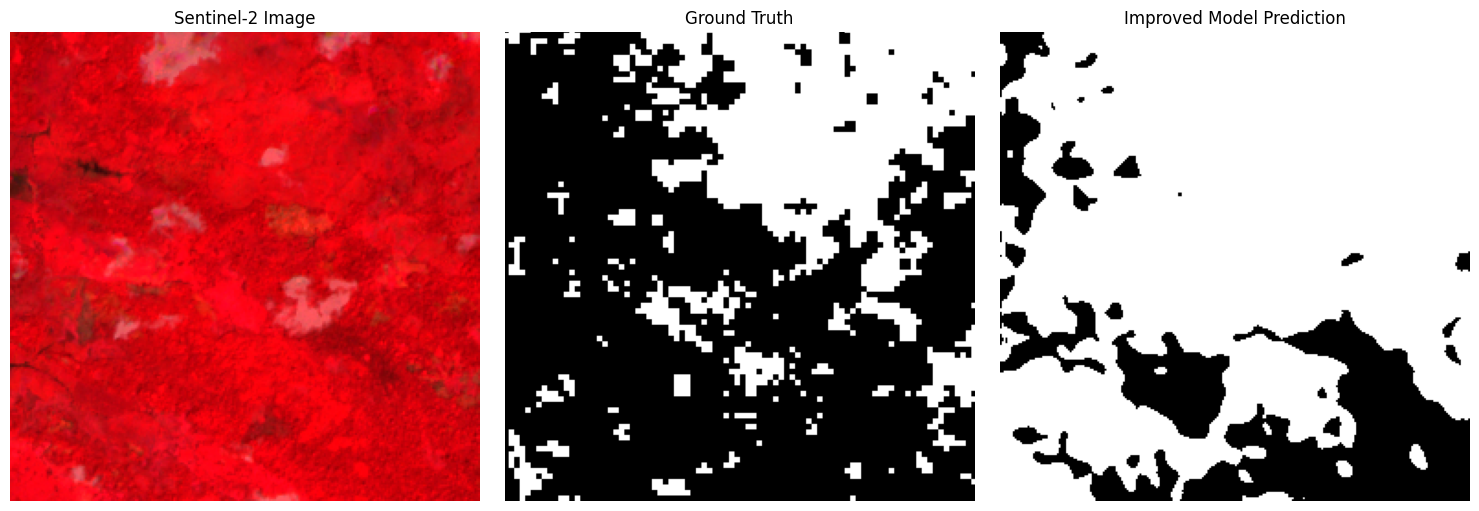

Saved: /content/drive/MyDrive/deforestation_project/outputs/prediction_maps/prediction_map_02.png


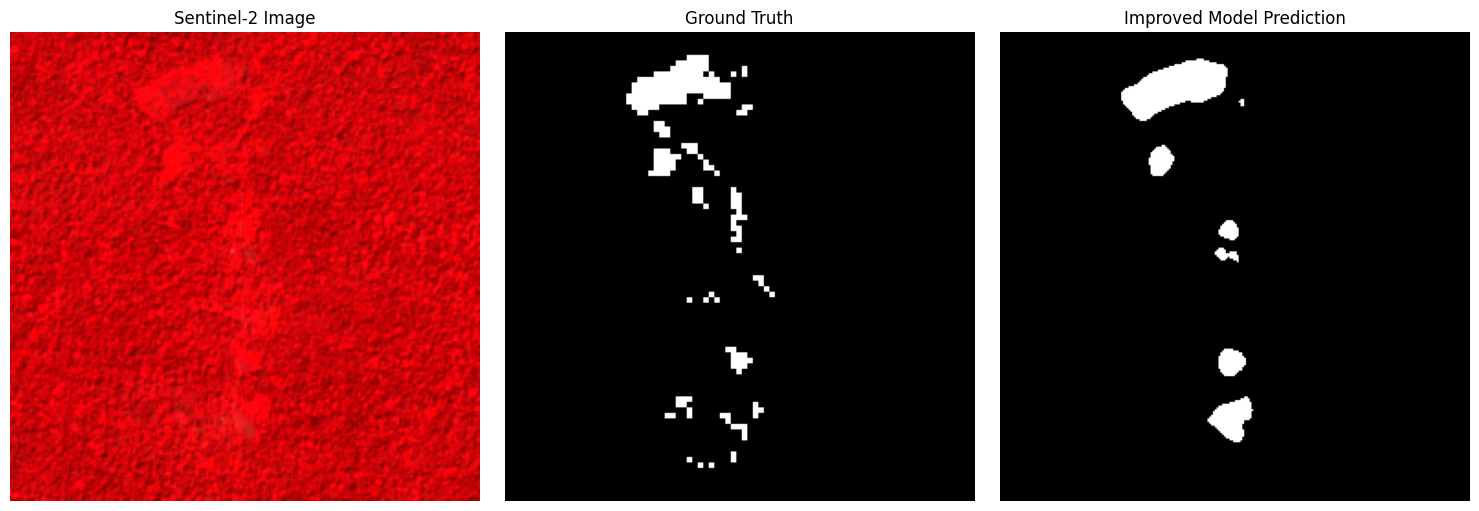

Saved: /content/drive/MyDrive/deforestation_project/outputs/prediction_maps/prediction_map_03.png


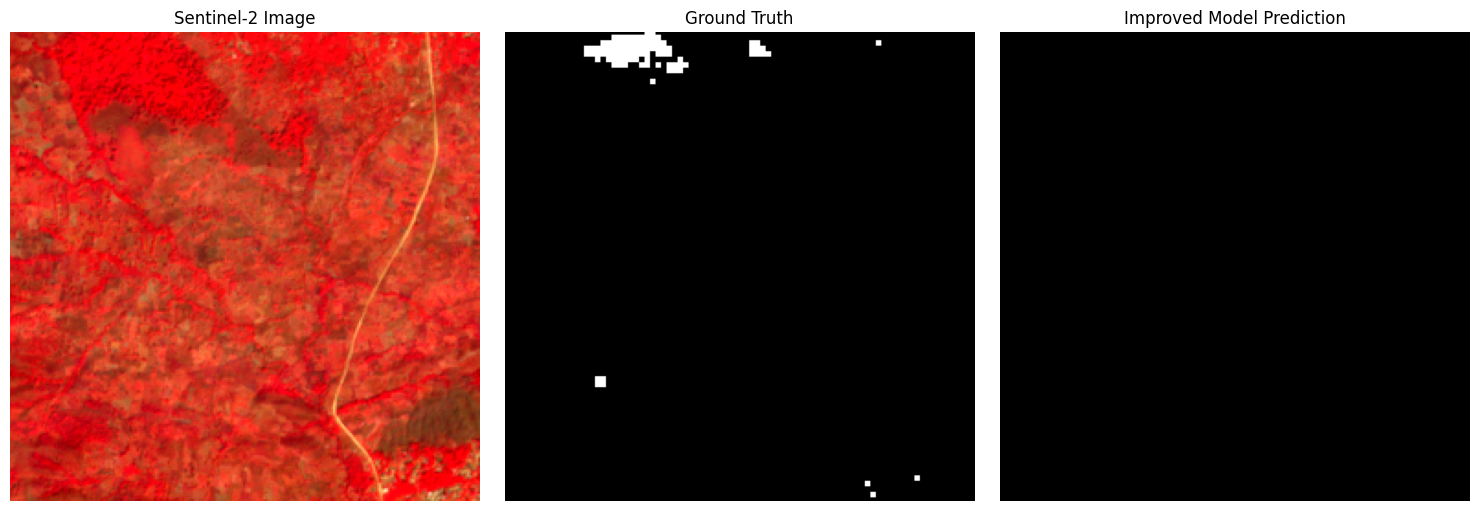

Saved: /content/drive/MyDrive/deforestation_project/outputs/prediction_maps/prediction_map_04.png


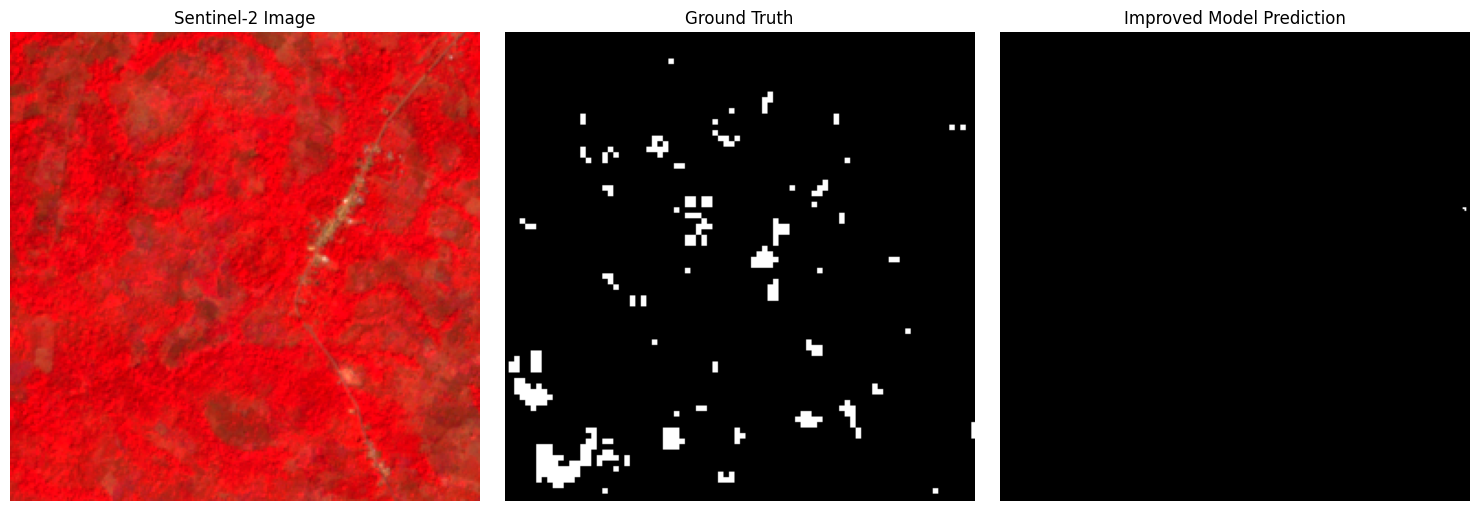

Saved: /content/drive/MyDrive/deforestation_project/outputs/prediction_maps/prediction_map_05.png


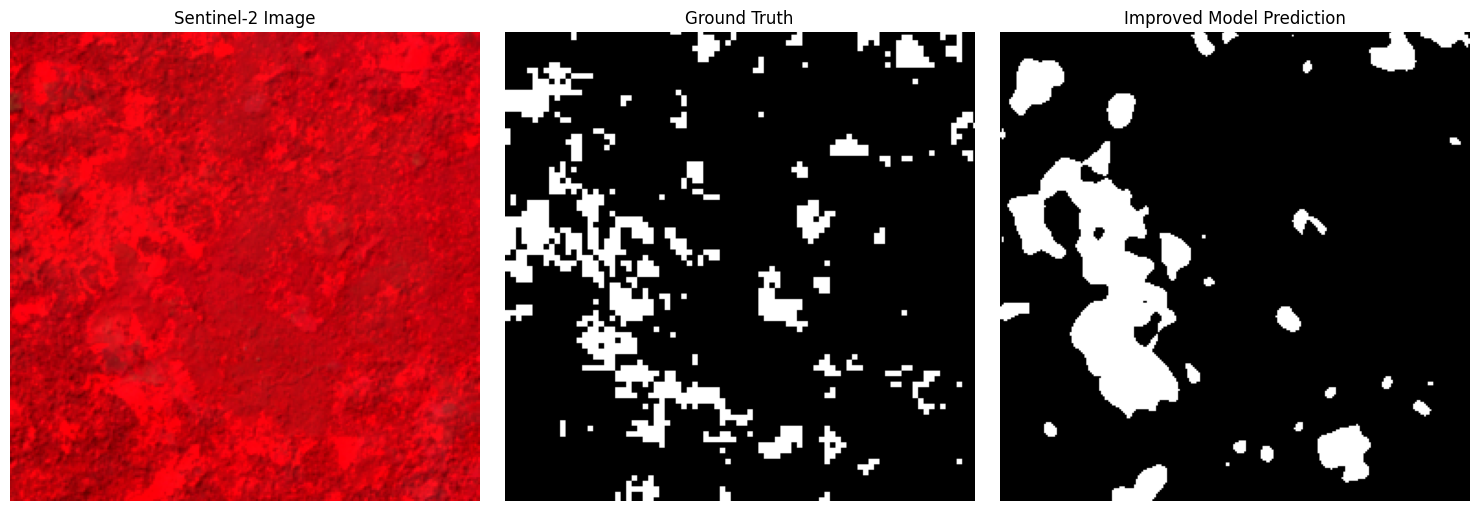

Saved: /content/drive/MyDrive/deforestation_project/outputs/prediction_maps/prediction_map_06.png

PREDICTION MAPS COMPLETE
Images saved: 6
Folder: /content/drive/MyDrive/deforestation_project/outputs/prediction_maps


In [23]:
# ============================================================
# FINAL PREDICTION MAPS — THRESHOLD 0.60
# Save figures for GitHub
# ============================================================

import os
import matplotlib.pyplot as plt
import numpy as np
import torch

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

BEST_THRESHOLD = 0.60

output_dir = (
    "/content/drive/MyDrive/"
    "deforestation_project/outputs/prediction_maps"
)

os.makedirs(output_dir, exist_ok=True)

improved_model.eval()

NUM_EXAMPLES = 6
shown = 0

# ------------------------------------------------------------
# Generate predictions
# ------------------------------------------------------------

with torch.no_grad():

    for batch_idx, (images, masks) in enumerate(test_loader):

        images_gpu = images.to(device)

        outputs = improved_model(images_gpu)

        probabilities = torch.sigmoid(outputs)

        predictions = (
            probabilities >= BEST_THRESHOLD
        ).float()

        for i in range(images.shape[0]):

            if shown >= NUM_EXAMPLES:
                break

            # ------------------------------------------------
            # Sentinel-2 image
            # ------------------------------------------------

            image = images[i].cpu().numpy()

            # First 3 bands → RGB
            rgb = image[:3]

            rgb_min = np.percentile(rgb, 2)
            rgb_max = np.percentile(rgb, 98)

            rgb = np.clip(
                (rgb - rgb_min) /
                (rgb_max - rgb_min + 1e-8),
                0,
                1
            )

            rgb = np.transpose(
                rgb,
                (1, 2, 0)
            )

            # ------------------------------------------------
            # Ground truth
            # ------------------------------------------------

            ground_truth = (
                masks[i]
                .squeeze()
                .cpu()
                .numpy()
            )

            # ------------------------------------------------
            # Prediction at final threshold
            # ------------------------------------------------

            prediction = (
                predictions[i]
                .squeeze()
                .cpu()
                .numpy()
            )

            # ------------------------------------------------
            # Create figure
            # ------------------------------------------------

            fig, axes = plt.subplots(
                1,
                3,
                figsize=(15, 5)
            )

            axes[0].imshow(rgb)
            axes[0].set_title(
                "Sentinel-2 Image",
                fontsize=12
            )
            axes[0].axis("off")

            axes[1].imshow(
                ground_truth,
                cmap="gray"
            )
            axes[1].set_title(
                "Ground Truth",
                fontsize=12
            )
            axes[1].axis("off")

            axes[2].imshow(
                prediction,
                cmap="gray"
            )
            axes[2].set_title(
                "Improved Model Prediction",
                fontsize=12
            )
            axes[2].axis("off")

            plt.tight_layout()

            # ------------------------------------------------
            # Save high-quality PNG
            # ------------------------------------------------

            filename = (
                f"prediction_map_{shown + 1:02d}.png"
            )

            save_path = os.path.join(
                output_dir,
                filename
            )

            plt.savefig(
                save_path,
                dpi=300,
                bbox_inches="tight"
            )

            plt.show()

            print(
                f"Saved: {save_path}"
            )

            plt.close(fig)

            shown += 1

        if shown >= NUM_EXAMPLES:
            break


print("\n" + "=" * 60)
print("PREDICTION MAPS COMPLETE")
print("=" * 60)
print(f"Images saved: {shown}")
print(f"Folder: {output_dir}")
print("=" * 60)

In [22]:
# ============================================================
# CHECK WHETHER MODEL PREDICTIONS ACTUALLY VARY
# ============================================================

import torch
import numpy as np

improved_model.eval()

print("=" * 65)
print("PREDICTION VARIATION CHECK")
print("=" * 65)

with torch.no_grad():

    batch_number = 0

    for images, masks in test_loader:

        images = images.to(device)

        outputs = improved_model(images)
        probabilities = torch.sigmoid(outputs)

        predictions = (
            probabilities >= 0.60
        )

        print(f"\nBatch {batch_number + 1}")

        for i in range(min(4, images.shape[0])):

            image = images[i].cpu()

            prob = probabilities[i].cpu()
            pred = predictions[i].cpu()

            print(
                f"Patch {i}: "
                f"Image mean={image.mean():.5f}, "
                f"Image std={image.std():.5f}, "
                f"Prob mean={prob.mean():.5f}, "
                f"Prob std={prob.std():.5f}, "
                f"Predicted %={100 * pred.float().mean():.2f}%"
            )

        batch_number += 1

        # Only inspect first 3 batches
        if batch_number >= 3:
            break

print("=" * 65)

PREDICTION VARIATION CHECK

Batch 1
Patch 0: Image mean=0.09199, Image std=0.09361, Prob mean=0.21310, Prob std=0.12700, Predicted %=1.86%
Patch 1: Image mean=0.10916, Image std=0.09599, Prob mean=0.71136, Prob std=0.16132, Predicted %=77.51%
Patch 2: Image mean=0.08119, Image std=0.08856, Prob mean=0.11406, Prob std=0.14455, Predicted %=3.09%
Patch 3: Image mean=0.11410, Image std=0.07179, Prob mean=0.12546, Prob std=0.06564, Predicted %=0.00%

Batch 2
Patch 0: Image mean=0.10383, Image std=0.08106, Prob mean=0.17077, Prob std=0.07579, Predicted %=0.00%
Patch 1: Image mean=0.09709, Image std=0.08670, Prob mean=0.34185, Prob std=0.19742, Predicted %=13.93%
Patch 2: Image mean=0.10628, Image std=0.07876, Prob mean=0.13716, Prob std=0.06601, Predicted %=0.00%
Patch 3: Image mean=0.07129, Image std=0.08647, Prob mean=0.10266, Prob std=0.09366, Predicted %=0.31%

Batch 3
Patch 0: Image mean=0.08389, Image std=0.09092, Prob mean=0.25812, Prob std=0.16904, Predicted %=5.70%
Patch 1: Image me

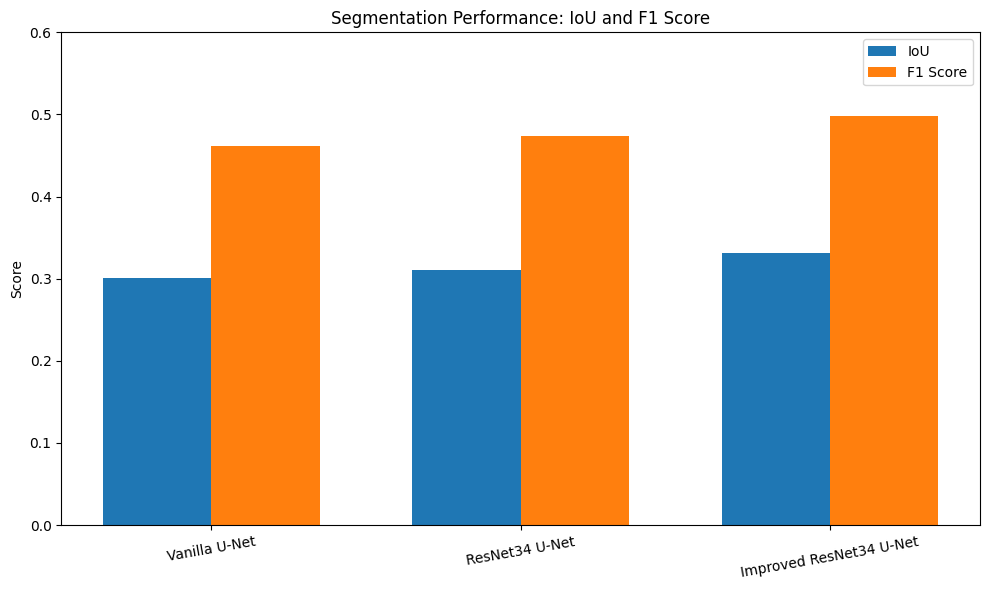

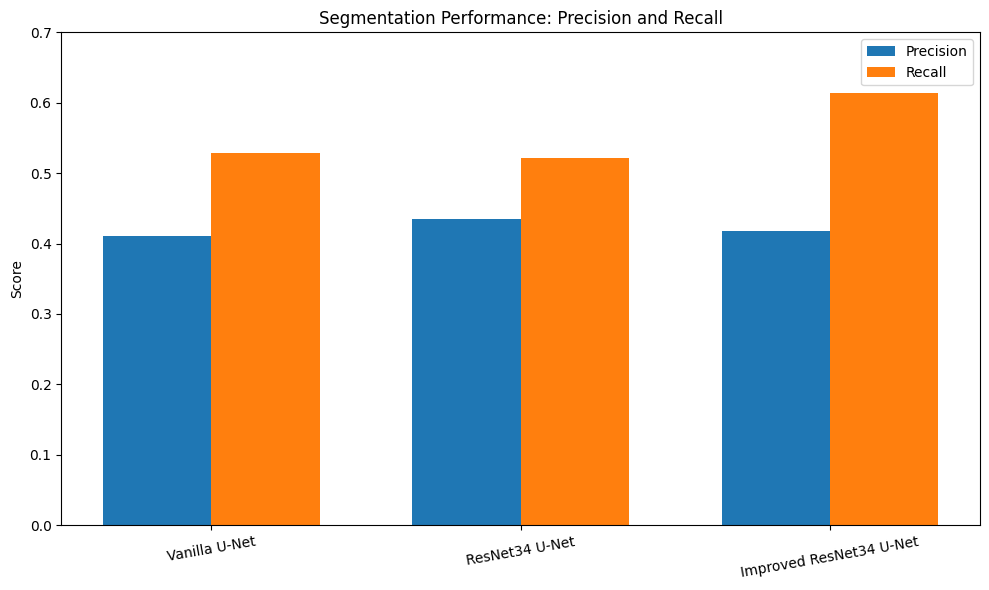

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

models = [
    "Vanilla U-Net",
    "ResNet34 U-Net",
    "Improved ResNet34 U-Net"
]

iou = [
    0.3006,
    0.3109,
    0.3312
]

precision = [
    0.4107,
    0.4348,
    0.4184
]

recall = [
    0.5284,
    0.5216,
    0.6137
]

f1 = [
    0.4622,
    0.4743,
    0.4976
]

accuracy = [
    0.8466,
    0.8558,
    0.8454
]

x = np.arange(len(models))

# ============================================================
# GRAPH 1 — IoU and F1
# ============================================================

width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    iou,
    width,
    label="IoU"
)

plt.bar(
    x + width/2,
    f1,
    width,
    label="F1 Score"
)

plt.xticks(x, models, rotation=10)
plt.ylabel("Score")
plt.title("Segmentation Performance: IoU and F1 Score")
plt.ylim(0, 0.6)
plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 2 — Precision and Recall
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    precision,
    width,
    label="Precision"
)

plt.bar(
    x + width/2,
    recall,
    width,
    label="Recall"
)

plt.xticks(x, models, rotation=10)
plt.ylabel("Score")
plt.title("Segmentation Performance: Precision and Recall")
plt.ylim(0, 0.7)
plt.legend()

plt.tight_layout()
plt.show()

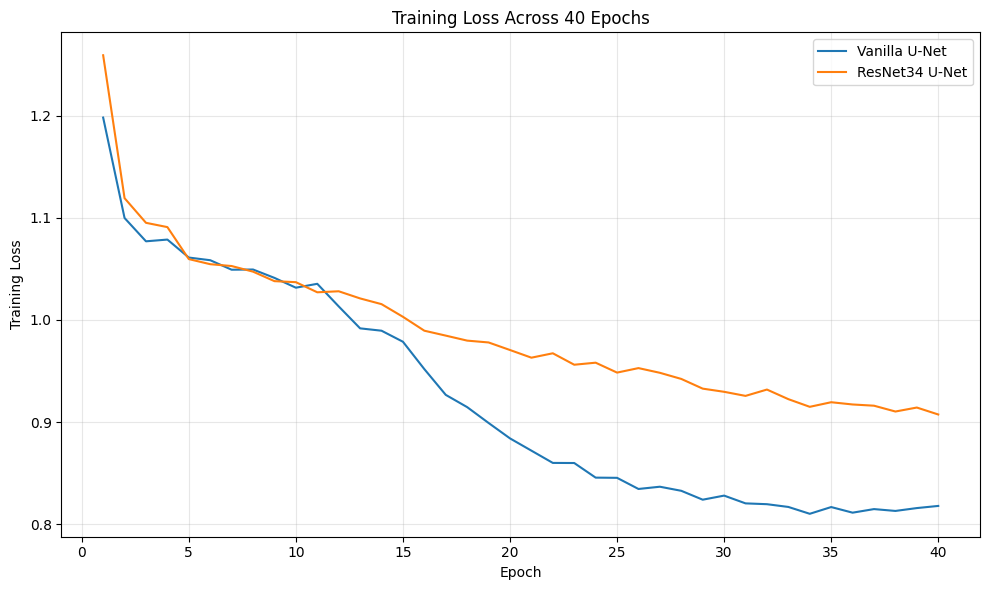

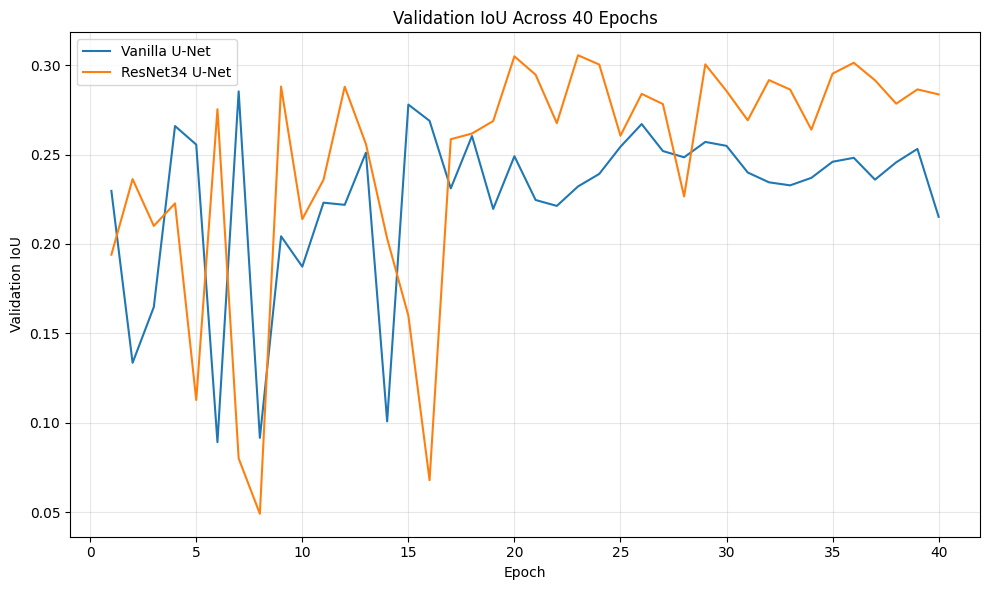

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# VANILLA U-NET — ACTUAL RECORDED TRAINING HISTORY
# ============================================================

vanilla_epochs = np.arange(1, 41)

vanilla_train_loss = [
    1.1980, 1.0997, 1.0769, 1.0786, 1.0610,
    1.0584, 1.0491, 1.0493, 1.0411, 1.0315,
    1.0353, 1.0132, 0.9917, 0.9894, 0.9786,
    0.9518, 0.9266, 0.9146, 0.8991, 0.8840,
    0.8720, 0.8600, 0.8599, 0.8456, 0.8454,
    0.8345, 0.8367, 0.8327, 0.8240, 0.8280,
    0.8204, 0.8196, 0.8169, 0.8102, 0.8168,
    0.8113, 0.8148, 0.8130, 0.8158, 0.8179
]

vanilla_val_iou = [
    0.2297, 0.1335, 0.1647, 0.2660, 0.2556,
    0.0891, 0.2854, 0.0915, 0.2043, 0.1873,
    0.2231, 0.2219, 0.2511, 0.1007, 0.2780,
    0.2689, 0.2311, 0.2604, 0.2196, 0.2491,
    0.2246, 0.2213, 0.2322, 0.2392, 0.2544,
    0.2671, 0.2520, 0.2485, 0.2571, 0.2549,
    0.2400, 0.2345, 0.2328, 0.2370, 0.2460,
    0.2482, 0.2360, 0.2457, 0.2532, 0.2152
]


# ============================================================
# RESNET34 U-NET — ACTUAL RECORDED TRAINING HISTORY
# ============================================================

resnet_epochs = np.arange(1, 41)

resnet_train_loss = [
    1.2590, 1.1191, 1.0950, 1.0908, 1.0595,
    1.0545, 1.0527, 1.0472, 1.0379, 1.0369,
    1.0270, 1.0280, 1.0210, 1.0154, 1.0030,
    0.9894, 0.9846, 0.9797, 0.9779, 0.9705,
    0.9630, 0.9673, 0.9561, 0.9581, 0.9484,
    0.9528, 0.9482, 0.9422, 0.9327, 0.9296,
    0.9256, 0.9318, 0.9224, 0.9149, 0.9194,
    0.9172, 0.9160, 0.9103, 0.9142, 0.9074
]

resnet_val_iou = [
    0.1940, 0.2363, 0.2101, 0.2227, 0.1127,
    0.2754, 0.0800, 0.0490, 0.2881, 0.2139,
    0.2359, 0.2880, 0.2559, 0.2031, 0.1599,
    0.0678, 0.2586, 0.2618, 0.2688, 0.3050,
    0.2947, 0.2676, 0.3056, 0.3004, 0.2606,
    0.2840, 0.2783, 0.2266, 0.3005, 0.2856,
    0.2692, 0.2917, 0.2864, 0.2640, 0.2953,
    0.3014, 0.2916, 0.2785, 0.2865, 0.2837
]


# ============================================================
# GRAPH 1 — TRAINING LOSS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    vanilla_epochs,
    vanilla_train_loss,
    label="Vanilla U-Net"
)

plt.plot(
    resnet_epochs,
    resnet_train_loss,
    label="ResNet34 U-Net"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Across 40 Epochs")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 2 — VALIDATION IoU
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    vanilla_epochs,
    vanilla_val_iou,
    label="Vanilla U-Net"
)

plt.plot(
    resnet_epochs,
    resnet_val_iou,
    label="ResNet34 U-Net"
)

plt.xlabel("Epoch")
plt.ylabel("Validation IoU")
plt.title("Validation IoU Across 40 Epochs")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

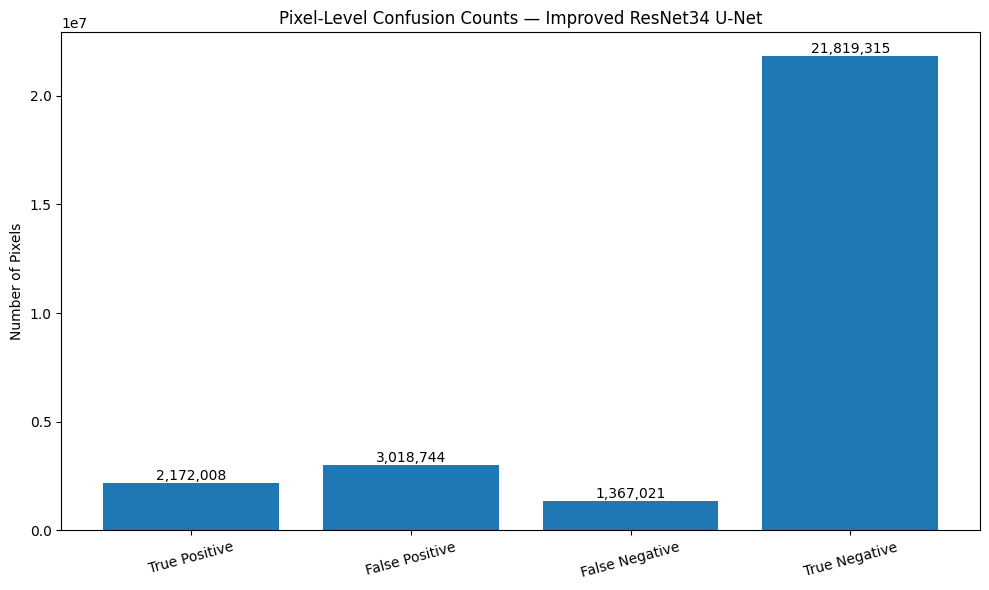

In [27]:
import matplotlib.pyplot as plt

# ============================================================
# FINAL IMPROVED MODEL — CONFUSION COUNTS
# ============================================================

labels = [
    "True Positive",
    "False Positive",
    "False Negative",
    "True Negative"
]

counts = [
    2172008,
    3018744,
    1367021,
    21819315
]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    labels,
    counts
)

plt.ylabel("Number of Pixels")
plt.title(
    "Pixel-Level Confusion Counts — Improved ResNet34 U-Net"
)

plt.xticks(rotation=15)

# Add values above bars
for bar, value in zip(bars, counts):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

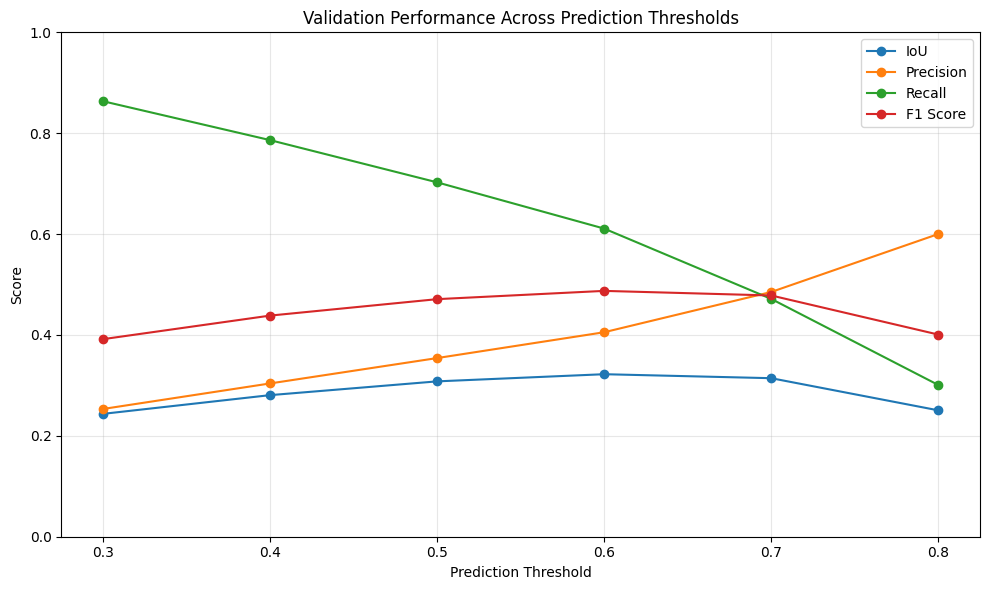

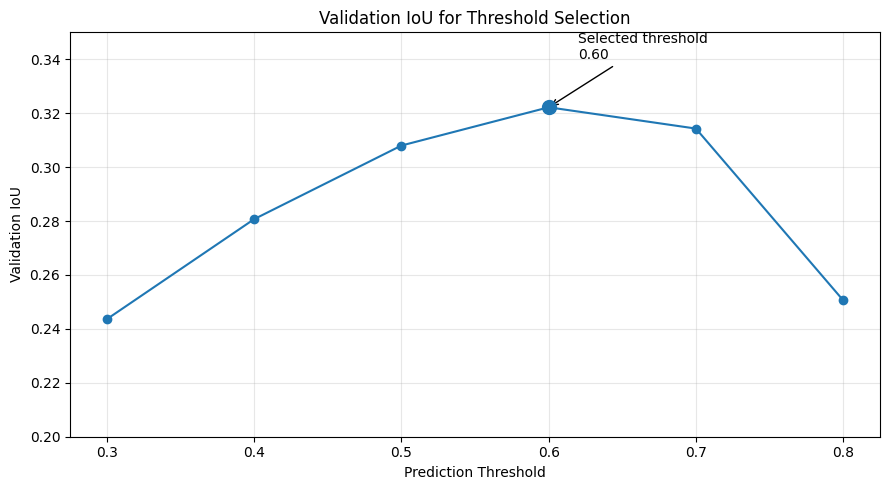

In [29]:
import matplotlib.pyplot as plt

# ============================================================
# VALIDATION THRESHOLD ANALYSIS
# ============================================================

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

val_iou = [
    0.2436,
    0.2807,
    0.3080,
    0.3222,
    0.3143,
    0.2506
]

val_precision = [
    0.2533,
    0.3039,
    0.3542,
    0.4054,
    0.4852,
    0.6001
]

val_recall = [
    0.8634,
    0.7863,
    0.7026,
    0.6109,
    0.4715,
    0.3009
]

val_f1 = [
    0.3917,
    0.4384,
    0.4710,
    0.4874,
    0.4783,
    0.4008
]

# ============================================================
# GRAPH 1 — ALL METRICS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    thresholds,
    val_iou,
    marker="o",
    label="IoU"
)

plt.plot(
    thresholds,
    val_precision,
    marker="o",
    label="Precision"
)

plt.plot(
    thresholds,
    val_recall,
    marker="o",
    label="Recall"
)

plt.plot(
    thresholds,
    val_f1,
    marker="o",
    label="F1 Score"
)

plt.xlabel("Prediction Threshold")
plt.ylabel("Score")
plt.title("Validation Performance Across Prediction Thresholds")
plt.xticks(thresholds)
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 2 — IoU ONLY
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    thresholds,
    val_iou,
    marker="o"
)

# Highlight selected threshold
plt.scatter(
    [0.60],
    [0.3222],
    s=100,
    zorder=5
)

plt.annotate(
    "Selected threshold\n0.60",
    xy=(0.60, 0.3222),
    xytext=(0.62, 0.34),
    arrowprops=dict(arrowstyle="->")
)

plt.xlabel("Prediction Threshold")
plt.ylabel("Validation IoU")
plt.title("Validation IoU for Threshold Selection")
plt.xticks(thresholds)
plt.ylim(0.20, 0.35)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
import pandas as pd

# ============================================================
# FINAL MODEL COMPARISON TABLE
# ============================================================

results = pd.DataFrame({
    "Model": [
        "Vanilla U-Net",
        "ResNet34 U-Net",
        "Improved ResNet34 U-Net"
    ],
    "IoU": [
        0.3006,
        0.3109,
        0.3312
    ],
    "Precision": [
        0.4107,
        0.4348,
        0.4184
    ],
    "Recall": [
        0.5284,
        0.5216,
        0.6137
    ],
    "F1 Score": [
        0.4622,
        0.4743,
        0.4976
    ],
    "Accuracy": [
        0.8466,
        0.8558,
        0.8454
    ]
})

# Display
display(results.round(4))

# ============================================================
# IMPROVEMENT: VANILLA → IMPROVED
# ============================================================

baseline = results.iloc[0]
final = results.iloc[2]

print("\n" + "=" * 65)
print("IMPROVEMENT: VANILLA U-NET → IMPROVED RESNET34 U-NET")
print("=" * 65)

for metric in [
    "IoU",
    "Precision",
    "Recall",
    "F1 Score",
    "Accuracy"
]:

    absolute_change = final[metric] - baseline[metric]
    percentage_change = (
        absolute_change /
        baseline[metric]
    ) * 100

    print(
        f"{metric:<12}: "
        f"{absolute_change:+.4f} "
        f"({percentage_change:+.2f}%)"
    )

,Model,IoU,Precision,Recall,F1 Score,Accuracy
0,Vanilla U-Net,0.3006,0.4107,0.5284,0.4622,0.8466
1,ResNet34 U-Net,0.3109,0.4348,0.5216,0.4743,0.8558
2,Improved ResNet34 U-Net,0.3312,0.4184,0.6137,0.4976,0.8454



IMPROVEMENT: VANILLA U-NET → IMPROVED RESNET34 U-NET
IoU         : +0.0306 (+10.18%)
Precision   : +0.0077 (+1.87%)
Recall      : +0.0853 (+16.14%)
F1 Score    : +0.0354 (+7.66%)
Accuracy    : -0.0012 (-0.14%)
